# Multi-Tier Automotive Supply Chain Risk Analysis Using Neo4j Graph Data Science

**Team Members:**
- Bekithemba Nkomo
- Peter Mangoro
- Masheia Dzimba

**Dataset:** Mendeley Automotive Production Network (12 facilities, 28,049 products, 87,059 BOM relationships)

**Platform:** Neo4j Desktop + Graph Data Science Library

---


## Executive summary

This notebook frames the dataset as an **OEM continuity decision problem**: if a supplier lane, component family, or facility is disrupted, which vehicle programs lose assembly throughput first and where should mitigation start. We build a **Neo4j** graph from the Moetz et al. (2020) automotive production-network workbook: **12 `Facility` sites**, **28,049 `Product` SKUs**, **87,059 BOM edges (`REQUIRES`)**, **11 inter-facility supplier lanes (`SHIPS_TO`)**, and **28,000 demand lines** over **14 periods**.

**Why a graph:** automotive BOM dependencies and inbound logistics are naturally **multi-hop**. Cypher expresses impact traversals (blast radius, dependency paths, chokepoint lanes) without hand-rolled recursive SQL.

**What decision support it delivers:** ranked structural risk hotspots, variant-sensitive component exposure, and action-ready priorities for sourcing resilience (dual sourcing, buffer placement, lane hardening).

**What this notebook is not:** The workbook is an **optimisation / research instance** (complete tables in-file, but not a full ERP). Claims below are about **this dataset**, not the whole automotive industry.


## Implementation Plan

**Project option selected:** This notebook follows **Option 2** from the final-project guidelines. It answers deeper analytical questions using Cypher and includes Graph Data Science analysis through in-memory projections, PageRank, and Leiden community detection.
This submission follows a compact implementation sequence:

1. **Define scope and graph semantics** (`Facility`, `Product`, `REQUIRES`, `SHIPS_TO`) and state dataset limits.
2. **Extract workbook tabs to CSV** with stable names used by Neo4j `LOAD CSV`.
3. **Run data quality checks** for nulls, key ranges, and cross-table key consistency before ingest.
4. **Apply temporal interpretation rules:** planning horizon (`61-74`), historical flows (`39-60`), and inventory snapshot (`60`).
5. **Create schema constraints and ingest in stages:** products/BOM first, then facilities/lanes, demand, inventory, and operational flows.
6. **Validate post-ingest counts and structure** before EDA and GDS analysis.


## Audience and Value

**Who uses this:** OEM supply-chain leaders, procurement planners, plant operations analysts, and technical reviewers in data science and engineering. The notebook is written so both audiences can follow the analysis: **business decisions first**, **Cypher and graph metrics second**.

**Qualitative Value:** faster **what-if triage** on vehicle variants and supplier lanes, including which SKUs and facilities are exposed if a component or arc fails, plus a shared evidence model for lead-time and capacity tradeoffs before action.

**Quantitative Value:** we report **counts and measures from this graph**, including dependency breadth, path volume, centrality, and lane fragility signals. We do **not** extrapolate to enterprise dollar ROI; any industry anecdotes in coursework are **illustrative**, not calibrated to this extract.


## Data extract & Neo4j model

**Workbook → CSV (12 files).** Rows are approximate for the published extract.

| CSV | Rows (≈) | Role |
|-----|----------|------|
| `products.csv` | 28,049 | Product catalog (`productId`, `group_g`, …) |
| `nodes.csv` | 12 | Facility IDs (`node_n`) |
| `arcs.csv` | 11 | Static lanes + lead time (`starting_node_i`, `ending_node_j`, `process_lead_time_l_ij`, …) |
| `BOM.csv` | 87,059 | BOM rows → `REQUIRES` parent/child + quantity |
| `demands.csv` | 28,000 | Demand by facility, product, period |
| `nodes_inflow.csv` | 44 | Who builds which SKU → `PRODUCES` |
| `initial_inventories.csv` | 82 | Opening stock → `HOLDS` |
| `capacity_at_arc.csv` | 154 | Per-period arc capacity |
| `initial_flows.csv` | 117 | Historical flows (periods 39–60) |
| `operations.csv` | 15 | Group-level transforms → `OUTPUTS_GROUP` / `USES_INPUT` |
| `max_flow_product_per_arc.csv` | 365 | Planned caps by product/arc/period |
| `max_flow_group_per_arc.csv` | 20 | Planned caps by group/arc/period |

**Neo4j labels (core):** `Facility` (secondary: `OEM`, `SupplierSite`, `Production`, `Inventory`), `Product`, `ProductGroup`, `Period`, `Customer`, `DemandFact`.

**Relationship types (core):** `SHIPS_TO` (logistics), `REQUIRES` (BOM), `BELONGS_TO`, `PRODUCES`; demand wiring `ORDERS`, `HAS_DEMAND`, `FOR_PRODUCT`, `IN_PERIOD`, `AT_NODE`; inventory `HOLDS`; plus `CAPACITY_AT`, `PLANNED_FLOW_TO`, `GROUP_FLOW_TO`, `INITIAL_FLOW_TO`, `OUTPUTS_GROUP`, `USES_INPUT` as loaded from the sheets.

**Join logic:** arcs join on facility strings in `nodes.csv`; BOM joins on mother/child product keys; demand joins on `node_n` + `product_p` + period.


## 1. Introduction

### 1.1 Problem

OEM teams need **assembly-continuity visibility**: if a supplier, component, or lane is stressed, which **vehicle SKUs**, **programs**, and **periods** are exposed first? Relational stacks are awkward for **recursive BOM** and **multi-hop supplier-lane** logic together; a graph expresses both in one model.

### 1.2 Why Neo4j

- **Pattern matching** over `REQUIRES` and `SHIPS_TO` in one query language.
- **Graph Data Science** for centrality / community metrics on the projected network.
- **Explicit schema** (labels and relationship types) shared between analysts and engineers.

### 1.3 Objectives

1. **Characterise** the automotive network: parts commonality, supplier-lane structure, demand concentration, and capacity coverage.
2. **Rank** high-impact facilities/components and **segment** structural dependency communities to support risk zoning.
3. **Stress-test** resilience levers: single-source exposure, cumulative lane delay, and bottlenecks against demand requirements.

### 1.4 Dataset

**Source:** Moetz, A., Quetschlich, M., Otto, B. (2020). *Optimisation model for multi-item multi-echelon supply chains with nested multi-level products.* Mendeley Data. DOI: [10.17632/pr3sdy5vp3.1](https://doi.org/10.17632/pr3sdy5vp3.1).

**Instance scale** (workbook): 12 facilities; 28,049 products; 87,059 `REQUIRES`; 11 `SHIPS_TO`; 14 demand periods in the planning window; product groups include `car`, `engine`, `gear`, `battery`, `seat`.

---


## 2. Environment setup and imports


In [4]:
from __future__ import annotations

import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from neo4j import GraphDatabase, basic_auth

warnings.filterwarnings("ignore")

# Project paths and expected source workbook.
ROOT = Path.cwd().resolve()
WORKBOOK = ROOT / "2020_dataset_OfAutomotiveProductionNetwork.xlsx"
EXPORT_DIR = ROOT / "data_export"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Visualization defaults used throughout the notebook.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

# Neo4j connection settings are read from .env when present, with local defaults.
load_dotenv(ROOT / ".env")
uri = os.environ.get("NEO4J_URI", "bolt://localhost:7687").strip()
user = os.environ.get("NEO4J_USER", "neo4j").strip()
password = os.environ.get("NEO4J_PASSWORD", "")
NEO4J_DATABASE = os.environ.get("NEO4J_DATABASE", "").strip() or None

driver = GraphDatabase.driver(uri, auth=basic_auth(user, password), database=NEO4J_DATABASE)
driver.verify_connectivity()

print("WORKBOOK exists:", WORKBOOK.is_file())
print("Connected:", uri, "| database:", NEO4J_DATABASE or "(default)")


def run_query(query, parameters=None):
    """Execute a Cypher query and return a pandas DataFrame."""
    parameters = parameters or {}
    sess_kw = {"database": NEO4J_DATABASE} if NEO4J_DATABASE else {}
    with driver.session(**sess_kw) as session:
        result = session.run(query, parameters)
        return pd.DataFrame([dict(record) for record in result])


run_query("RETURN 1 AS ok")

WORKBOOK exists: True
Connected: bolt://localhost:7687 | database: finalcapstone


,ok
0,1


## 3. Extract workbook tabs to CSV (`.xlsx`)

Expected sheets (from proposal): `products`, `nodes`, `nodes_inflow`, `arcs`, `capacity_at_arc`, `max_flow_product_per_arc`, `max_flow_group_per_arc`, `operations`, `BOM`, `demands`, `initial_inventories`, `initial_flows`.

**Neo4j `LOAD CSV`:** copy needed files into the database **import** directory; use `file:///filename.csv` in Cypher.


In [5]:
EXPECTED_SHEETS = [
    "products",
    "nodes",
    "nodes_inflow",
    "arcs",
    "capacity_at_arc",
    "max_flow_product_per_arc",
    "max_flow_group_per_arc",
    "operations",
    "BOM",
    "demands",
    "initial_inventories",
    "initial_flows",
]

if not WORKBOOK.is_file():
    print(
        "MISSING workbook. Download from Mendeley and save as:\n ",
        WORKBOOK.name,
    )
else:
    # Use default engine resolution for .xlsx
    xl = pd.ExcelFile(WORKBOOK)
    available = set(xl.sheet_names)
    print("Sheets in file:", len(available))
    exported = []
    missing = []
    for name in EXPECTED_SHEETS:
        if name not in available:
            # try case-insensitive
            lower = {s.lower(): s for s in available}
            key = name.lower()
            if key in lower:
                name = lower[key]
            else:
                missing.append(name)
                continue
        df = pd.read_excel(WORKBOOK, sheet_name=name)
        out = EXPORT_DIR / f"{name}.csv"
        df.to_csv(out, index=False, encoding="utf-8")
        exported.append((name, len(df), len(df.columns)))
    for row in exported:
        print(f"  {row[0]}: {row[1]} rows × {row[2]} cols -> {row[0]}.csv")
    if missing:
        print("NOT FOUND (check exact sheet names in workbook):", missing)

Sheets in file: 12
  products: 28049 rows × 3 cols -> products.csv
  nodes: 12 rows × 1 cols -> nodes.csv
  nodes_inflow: 44 rows × 2 cols -> nodes_inflow.csv
  arcs: 11 rows × 4 cols -> arcs.csv
  capacity_at_arc: 154 rows × 4 cols -> capacity_at_arc.csv
  max_flow_product_per_arc: 365 rows × 5 cols -> max_flow_product_per_arc.csv
  max_flow_group_per_arc: 20 rows × 5 cols -> max_flow_group_per_arc.csv
  operations: 15 rows × 7 cols -> operations.csv
  BOM: 87059 rows × 3 cols -> BOM.csv
  demands: 28000 rows × 4 cols -> demands.csv
  initial_inventories: 82 rows × 6 cols -> initial_inventories.csv
  initial_flows: 117 rows × 5 cols -> initial_flows.csv


## 4. Schema constraints

**Reset:** Full wipe of this database before rebuilding the graph.

- Drops **all** constraints returned by `SHOW CONSTRAINTS`.
- Runs **`MATCH (n) DETACH DELETE n`** once, removing every node and all attached relationships.

**Create:** Create uniqueness on `Facility.nodeId`, `Product.productId`, `ProductGroup.groupName`, `Period.periodId`, `DemandFact.demandKey`, and `Customer.customerId`.


In [6]:
#  Full database reset 
def _qc_constraint(n: str) -> str:
    inner = str(n).strip().strip("`").replace("`", "``")
    return f"`{inner}`"


constraints_df = run_query(
    """
    SHOW CONSTRAINTS
    YIELD name AS constraintName
    RETURN constraintName AS name
    ORDER BY name
    """
)

n_drop = 0
if not constraints_df.empty and "name" in constraints_df.columns:
    for nm in constraints_df["name"].dropna().astype(str):
        run_query(f"DROP CONSTRAINT {_qc_constraint(nm)} IF EXISTS")
        n_drop += 1

run_query("MATCH (n) DETACH DELETE n")
print("Graph successfully cleared.")


Graph successfully cleared.


In [7]:
# Create supply-chain uniqueness constraints


constraint_cypher = [
 "CREATE CONSTRAINT supply_facility_nodeid IF NOT EXISTS FOR (n:Facility) REQUIRE n.nodeId IS UNIQUE",
 "CREATE CONSTRAINT supply_product_productid IF NOT EXISTS FOR (p:Product) REQUIRE p.productId IS UNIQUE",
 "CREATE CONSTRAINT supply_productgroup_groupname IF NOT EXISTS FOR (g:ProductGroup) REQUIRE g.groupName IS UNIQUE",
 "CREATE CONSTRAINT supply_period_periodid IF NOT EXISTS FOR (t:Period) REQUIRE t.periodId IS UNIQUE",
 "CREATE CONSTRAINT supply_demandfact_demandkey IF NOT EXISTS FOR (f:DemandFact) REQUIRE f.demandKey IS UNIQUE",
 "CREATE CONSTRAINT supply_customer_customerid IF NOT EXISTS FOR (c:Customer) REQUIRE c.customerId IS UNIQUE",
]

for stmt in constraint_cypher:
 run_query(stmt)

display(
 run_query(
 """
 SHOW CONSTRAINTS
 YIELD name, type, entityType, labelsOrTypes, properties
 RETURN name, type, entityType, labelsOrTypes, properties
 ORDER BY name
 """
 )
)

,name,type,entityType,labelsOrTypes,properties
0,supply_customer_customerid,NODE_PROPERTY_UNIQUENESS,NODE,[Customer],[customerId]
1,supply_demandfact_demandkey,NODE_PROPERTY_UNIQUENESS,NODE,[DemandFact],[demandKey]
2,supply_facility_nodeid,NODE_PROPERTY_UNIQUENESS,NODE,[Facility],[nodeId]
3,supply_period_periodid,NODE_PROPERTY_UNIQUENESS,NODE,[Period],[periodId]
4,supply_product_productid,NODE_PROPERTY_UNIQUENESS,NODE,[Product],[productId]
5,supply_productgroup_groupname,NODE_PROPERTY_UNIQUENESS,NODE,[ProductGroup],[groupName]


## 5. Ingest

This notebook assumes the following CSVs are available in the database `import` directory (the `file:///` filenames in Cypher):
- `demands.csv`
- `products.csv`
- `BOM.csv`
- `nodes.csv`
- `arcs.csv`
- `nodes_inflow.csv`
- `initial_inventories.csv`
- `operations.csv`
- `capacity_at_arc.csv`
- `max_flow_product_per_arc.csv`
- `max_flow_group_per_arc.csv`
- `initial_flows.csv`

### Period, products, BOM (`LOAD CSV`)

Materializes the time and product hierarchy: distinct `(:Period)` values, `(:ProductGroup)` and `(:Product)` entities (with `Product.productId` stored as a trimmed string), and `(:Product)-[:BELONGS_TO]->(:ProductGroup)` relationships. It also establishes BOM-based dependencies via `(:Product)-[:REQUIRES {quantity, source:'BOM',...}]->(:Product)` edges with `catalogSource` normalized on endpoints to `'products_sheet'`, `'BOM_only'`, or BOM-derived attribution as appropriate.

This step sets the foundation used by subsequent ingest steps for `REQUIRES`, `SHIPS_TO`, and all time-varying capacity/flow relationships.

### Network nodes, arcs, facility-product, demand facts, inventory, operations

Adds `(:Facility)` and secondary node labels (`OEM`, `SupplierSite`, `Production`, `Inventory`), static inter-facility logistics arcs `(:Facility)-[:SHIPS_TO {leadTime, productGroup, arcKey}]->(:Facility)`, facility-to-product production links (`PRODUCES`), demand wiring (`Customer` -> `ORDERS` -> `DemandFact`, plus `HAS_DEMAND`, `FOR_PRODUCT`, `IN_PERIOD`, `AT_NODE`), opening/held inventory (`HOLDS` with `periodId`), and operational relations (`OUTPUTS_GROUP` and `USES_INPUT`).

### Time-varying arc capacity and flows

Creates per-period capacity and planned/initial flows aligned to the same `arcKey` used by `SHIPS_TO`: `CAPACITY_AT`, `PLANNED_FLOW_TO`, `GROUP_FLOW_TO`, and `INITIAL_FLOW_TO`. Lead time remains carried by `SHIPS_TO`, while capacity/flow varies by `periodId` and by product/group identity where relevant.


In [8]:
# — LOAD CSV: Period, ProductGroup/Product/BELONGS_TO, BOM/REQUIRES

period_cypher = """
LOAD CSV WITH HEADERS FROM 'file:///demands.csv' AS row
WITH DISTINCT row.period_t AS pt
WHERE pt IS NOT NULL AND trim(toString(pt)) <> ''
MERGE (:Period {periodId: toInteger(pt)})
"""
run_query(period_cypher)

products_cypher = """
LOAD CSV WITH HEADERS FROM 'file:///products.csv' AS row
WITH row,
 trim(toString(row.product_p)) AS pp,
 trim(toString(row.group_g)) AS gg
WHERE pp <> '' AND gg <> ''
MERGE (pg:ProductGroup {groupName: gg})
MERGE (pr:Product {productId: pp})
SET pr.transportationSize = coalesce(toInteger(trim(toString(row.transportation_size_s))), 0),
 pr.catalogSource = 'products_sheet'
MERGE (pr)-[:BELONGS_TO]->(pg)
"""
run_query(products_cypher)

bom_cypher = """
LOAD CSV WITH HEADERS FROM 'file:///BOM.csv' AS row
WITH row,
 trim(toString(row.mother)) AS mraw,
 trim(toString(row.child)) AS craw
WHERE mraw <> '' AND craw <> ''
MERGE (parent:Product {productId: mraw})
MERGE (child:Product {productId: craw})
MERGE (parent)-[req:REQUIRES]->(child)
SET req.quantity = coalesce(toInteger(trim(toString(row.individual_input_quantity_q_mc))), 0),
 req.source = 'BOM',
 parent.catalogSource = coalesce(parent.catalogSource, 'BOM_only'),
 child.catalogSource = coalesce(child.catalogSource, 'BOM_only')
"""
run_query(bom_cypher)

display(run_query("MATCH (p:Period) RETURN count(p) AS periods"))
display(run_query("MATCH (pr:Product) RETURN count(pr) AS products"))
display(run_query("MATCH (pg:ProductGroup) RETURN count(pg) AS product_groups"))
display(run_query("MATCH ()-[b:BELONGS_TO]->() RETURN count(b) AS belongs_to"))
display(run_query("MATCH ()-[r:REQUIRES]->() RETURN count(r) AS requires"))
display(
 run_query(
 "MATCH (p:Product) WHERE p.catalogSource = 'products_sheet' RETURN count(p) AS products_from_sheet"
 )
)
display(
 run_query(
 "MATCH (p:Product) WHERE p.catalogSource = 'BOM_only' RETURN count(p) AS products_bom_only"
 )
)
display(run_query("MATCH ()-[r:REQUIRES]->() WHERE r.source = 'BOM' RETURN count(r) AS requires_with_bom_source"))

,periods
0,14


,products
0,28049


,product_groups
0,7


,belongs_to
0,28049


,requires
0,87059


,products_from_sheet
0,28049


,products_bom_only
0,0


,requires_with_bom_source
0,87059


### Network nodes, arcs, facility–product, demand facts, inventory, operations

In [9]:
# — LOAD CSV: Facility (+ domain labels), SHIPS_TO (+arcKey), PRODUCES, DemandFact + Customer,
# HOLDS, OUTPUTS_GROUP + USES_INPUT


nodes_cypher = """
LOAD CSV WITH HEADERS FROM 'file:///nodes.csv' AS row
WITH trim(toString(row.node_n)) AS nn
WHERE nn <> ''
MERGE (:Facility {nodeId: nn})
"""
run_query(nodes_cypher)

_node_label_queries = [
 """MATCH (n:Facility)
SET n.displayName = n.nodeId,
 n.siteKind = CASE WHEN n.nodeId IN ['zp7', 'zp8'] THEN 'OEM' ELSE 'supplier' END""",
 "MATCH (n:Facility) WHERE n.nodeId IN ['zp7', 'zp8'] SET n:OEM",
 "MATCH (n:Facility) WHERE NOT n.nodeId IN ['zp7', 'zp8'] SET n:SupplierSite",
 "MATCH (n:Facility) WHERE n.nodeId ENDS WITH '_prod' SET n:Production",
 "MATCH (n:Facility) WHERE n.nodeId ENDS WITH '_inv' SET n:Inventory",
]
for _q in _node_label_queries:
 run_query(_q)

arcs_cypher = """
LOAD CSV WITH HEADERS FROM 'file:///arcs.csv' AS row
WITH trim(toString(row.starting_node_i)) AS si,
 trim(toString(row.ending_node_j)) AS ej,
 row
WHERE si <> '' AND ej <> ''
MERGE (a:Facility {nodeId: si})
MERGE (b:Facility {nodeId: ej})
MERGE (a)-[s:SHIPS_TO]->(b)
SET s.leadTime = coalesce(toInteger(trim(toString(row.process_lead_time_l_ij))), 0),
 s.productGroup = trim(toString(row.group_g)),
 s.arcKey = si + '|' + ej
"""
run_query(arcs_cypher)

produces_cypher = """
LOAD CSV WITH HEADERS FROM 'file:///nodes_inflow.csv' AS row
WITH trim(toString(row.node_n)) AS nn,
 trim(toString(row.product_p)) AS pid
WHERE nn <> '' AND pid <> ''
MERGE (n:Facility {nodeId: nn})
MERGE (pr:Product {productId: pid})
MERGE (n)-[:PRODUCES]->(pr)
"""
run_query(produces_cypher)

demands_cypher = """
LOAD CSV WITH HEADERS FROM 'file:///demands.csv' AS row
WITH trim(toString(row.node_n)) AS nn,
 trim(toString(row.product_p)) AS pid,
 row
WHERE nn <> '' AND pid <> ''
WITH nn, pid, row, trim(toString(row.period_t)) AS ptc
WHERE ptc <> ''
WITH nn, pid, row, toInteger(ptc) AS pt
WHERE pt IS NOT NULL
MERGE (cust:Customer {customerId: 'market'})
MERGE (n:Facility {nodeId: nn})
MERGE (pr:Product {productId: pid})
MERGE (t:Period {periodId: pt})
MERGE (f:DemandFact {demandKey: nn + '::' + pid + '::' + toString(pt)})
SET f.quantity = coalesce(toInteger(trim(toString(row.demand_d_npt))), 0)
MERGE (cust)-[:ORDERS]->(f)
MERGE (n)-[:HAS_DEMAND]->(f)
MERGE (f)-[:FOR_PRODUCT]->(pr)
MERGE (f)-[:IN_PERIOD]->(t)
MERGE (f)-[:AT_NODE]->(n)
"""
run_query(demands_cypher)

holds_cypher = """
LOAD CSV WITH HEADERS FROM 'file:///initial_inventories.csv' AS row
WITH trim(toString(row.node_n)) AS nn,
 trim(toString(row.product_p)) AS pid,
 row
WHERE nn <> '' AND pid <> ''
WITH nn, pid, row, trim(toString(row.period_t)) AS ptc
WHERE ptc <> ''
WITH nn, pid, row, toInteger(ptc) AS pt
WHERE pt IS NOT NULL
MERGE (n:Facility {nodeId: nn})
MERGE (pr:Product {productId: pid})
MERGE (n)-[h:HOLDS {periodId: pt}]->(pr)
SET h.initialInventory = coalesce(toInteger(trim(toString(row.initial_inventory_I_np0))), 0),
 h.safetyStock = coalesce(toInteger(trim(toString(row.safety_stock))), 0),
 h.maxInventory = coalesce(toInteger(trim(toString(row.max_inventory))), 0)
"""
run_query(holds_cypher)

operations_cypher = """
LOAD CSV WITH HEADERS FROM 'file:///operations.csv' AS row
WITH trim(toString(row.node_n)) AS nn,
 trim(toString(row.input_product_group_x)) AS gx,
 trim(toString(row.output_product_group_y)) AS gy,
 row
WHERE nn <> '' AND gx <> '' AND gy <> ''
MERGE (n:Facility {nodeId: nn})
MERGE (gout:ProductGroup {groupName: gy})
MERGE (gin:ProductGroup {groupName: gx})
MERGE (n)-[out:OUTPUTS_GROUP {inputGroup: gx}]->(gout)
SET out.outputGroup = gy,
 out.inputQty = coalesce(toInteger(trim(toString(row.input_quantity_in_nxy))), 0),
 out.outputQty = coalesce(toInteger(trim(toString(row.output_quantity_out_nxy))), 0),
 out.alpha = coalesce(toFloat(trim(toString(row.alpha_nxy))), 0.0),
 out.beta = coalesce(toFloat(trim(toString(row.beta_nxy))), 0.0)
MERGE (n)-[inp:USES_INPUT {inputGroup: gx}]->(gin)
"""
run_query(operations_cypher)

display(run_query("MATCH (n:Facility) RETURN count(n) AS supply_facilities"))
display(run_query("MATCH (n:OEM) RETURN count(n) AS oem_nodes"))
display(run_query("MATCH ()-[s:SHIPS_TO]->() RETURN count(s) AS ships_to"))
display(run_query("MATCH ()-[p:PRODUCES]->() RETURN count(p) AS produces"))
display(run_query("MATCH (f:DemandFact) RETURN count(f) AS demand_facts"))
display(run_query("MATCH (c:Customer) RETURN count(c) AS customers"))
display(run_query("MATCH ()-[r:HAS_DEMAND]->() RETURN count(r) AS has_demand"))
display(run_query("MATCH ()-[r:ORDERS]->() RETURN count(r) AS orders"))
display(run_query("MATCH ()-[r:AT_NODE]->() RETURN count(r) AS at_node"))
display(run_query("MATCH ()-[r:FOR_PRODUCT]->() RETURN count(r) AS for_product"))
display(run_query("MATCH ()-[r:IN_PERIOD]->() RETURN count(r) AS in_period"))
display(run_query("MATCH ()-[ho:HOLDS]->() RETURN count(ho) AS holds"))
display(run_query("MATCH ()-[o:OUTPUTS_GROUP]->() RETURN count(o) AS outputs_group"))
display(run_query("MATCH ()-[u:USES_INPUT]->() RETURN count(u) AS uses_input"))

,supply_facilities
0,12


,oem_nodes
0,2


,ships_to
0,11


,produces
0,44


,demand_facts
0,28000


...

,for_product
0,28000


,in_period
0,28000


,holds
0,82


,outputs_group
0,15


,uses_input
0,15


### Time-varying arc capacity and flows

In [10]:
# — LOAD CSV: CAPACITY_AT, PLANNED_FLOW_TO, GROUP_FLOW_TO, INITIAL_FLOW_TO


capacity_cypher = """
LOAD CSV WITH HEADERS FROM 'file:///capacity_at_arc.csv' AS row
WITH trim(toString(row.starting_node_i)) AS si,
 trim(toString(row.ending_node_j)) AS ej,
 trim(toString(row.period_t)) AS ptc,
 row
WHERE si <> '' AND ej <> '' AND ptc <> ''
WITH si, ej, row, toInteger(ptc) AS pt
WHERE pt IS NOT NULL
MERGE (a:Facility {nodeId: si})
MERGE (b:Facility {nodeId: ej})
MERGE (a)-[c:CAPACITY_AT {periodId: pt}]->(b)
SET c.capacity = coalesce(toInteger(trim(toString(row.capacity_c_ijt))), 0),
 c.arcKey = si + '|' + ej
"""
run_query(capacity_cypher)

planned_product_cypher = """
LOAD CSV WITH HEADERS FROM 'file:///max_flow_product_per_arc.csv' AS row
WITH trim(toString(row.starting_node_i)) AS si,
 trim(toString(row.ending_node_j)) AS ej,
 trim(toString(row.product_p)) AS pid,
 trim(toString(row.period_t)) AS ptc,
 row
WHERE si <> '' AND ej <> '' AND pid <> '' AND ptc <> ''
WITH si, ej, pid, row, toInteger(ptc) AS pt
WHERE pt IS NOT NULL
MERGE (a:Facility {nodeId: si})
MERGE (b:Facility {nodeId: ej})
MERGE (a)-[f:PLANNED_FLOW_TO {periodId: pt, productId: pid}]->(b)
SET f.plannedFlow = coalesce(toInteger(trim(toString(row.planned_flow))), 0),
 f.arcKey = si + '|' + ej
"""
run_query(planned_product_cypher)

planned_group_cypher = """
LOAD CSV WITH HEADERS FROM 'file:///max_flow_group_per_arc.csv' AS row
WITH trim(toString(row.starting_node_i)) AS si,
 trim(toString(row.ending_node_j)) AS ej,
 trim(toString(row.group_g)) AS gn,
 trim(toString(row.period_t)) AS ptc,
 row
WHERE si <> '' AND ej <> '' AND gn <> '' AND ptc <> ''
WITH si, ej, gn, row, toInteger(ptc) AS pt
WHERE pt IS NOT NULL
MERGE (a:Facility {nodeId: si})
MERGE (b:Facility {nodeId: ej})
MERGE (a)-[g:GROUP_FLOW_TO {periodId: pt, productGroup: gn}]->(b)
SET g.plannedFlow = coalesce(toInteger(trim(toString(row.planned_flow))), 0),
 g.arcKey = si + '|' + ej
"""
run_query(planned_group_cypher)

initial_flow_cypher = """
LOAD CSV WITH HEADERS FROM 'file:///initial_flows.csv' AS row
WITH trim(toString(row.starting_node_i)) AS si,
 trim(toString(row.ending_node_j)) AS ej,
 trim(toString(row.product_p)) AS pid,
 trim(toString(row.period_t)) AS ptc,
 row
WHERE si <> '' AND ej <> '' AND pid <> '' AND ptc <> ''
WITH si, ej, pid, row, toInteger(ptc) AS pt
WHERE pt IS NOT NULL
MERGE (a:Facility {nodeId: si})
MERGE (b:Facility {nodeId: ej})
MERGE (a)-[init:INITIAL_FLOW_TO {periodId: pt, productId: pid}]->(b)
SET init.initialFlow = coalesce(toInteger(trim(toString(row.initial_flow))), 0),
 init.arcKey = si + '|' + ej
"""
run_query(initial_flow_cypher)

display(run_query("MATCH ()-[c:CAPACITY_AT]->() RETURN count(c) AS capacity_at"))
display(run_query("MATCH ()-[f:PLANNED_FLOW_TO]->() RETURN count(f) AS planned_flow_product"))
display(run_query("MATCH ()-[g:GROUP_FLOW_TO]->() RETURN count(g) AS planned_flow_group"))
display(run_query("MATCH ()-[x:INITIAL_FLOW_TO]->() RETURN count(x) AS initial_flow_to"))
display(
 run_query(
 """
 MATCH ()-[c:CAPACITY_AT]->()
 RETURN count(*) AS capacity_rels, count(c.arcKey) AS capacity_with_arckey
 """
 )
)

,capacity_at
0,154


,planned_flow_product
0,365


,planned_flow_group
0,20


,initial_flow_to
0,117


,capacity_rels,capacity_with_arckey
0,154,154


## 6. Graph EDA

### Assumptions and interpretation guardrails

To keep recommendations decision-grade for an automotive audience, findings in later sections use these assumptions:

1. **Variant-mix assumption (battery optionality):** not every car SKU in this extract has a direct tier-1 battery dependency. This is interpreted as a mixed portfolio, such as ICE-oriented and battery-equipped variants, or battery represented as configuration-specific BOM coverage.
2. **Dataset-scope assumption:** this is a research/optimization instance, not a full ERP mirror. We use results for relative prioritization, not absolute enterprise-wide commitments.
3. **Planning-window assumption:** periods `61-74` represent active planning analysis, while period `60` inventory and earlier flow periods provide starting-state context.
4. **Structural-risk assumption:** high parts commonality and long-delay supplier lanes increase line-stoppage blast radius when disrupted.
5. **Data-linkage assumption:** missing producer/supplier linkage for a component is treated as a data-quality gap until validated, not as evidence of low operational risk.


### EDA 1: How are major entity layers and relationship families distributed in the loaded graph?

**Query logic:** We run two Cypher blocks: 

(1) a `UNION ALL` of `MATCH … count` over each main layer `Facility`, `Product`, `ProductGroup`, `Period`, `DemandFact`, and `Customer` to tabulate node counts by semantic layer. 

(2) `MATCH ()-[r]->()` with `RETURN type(r), count(r)` to list every relationship family and its frequency, ordered descending by volume. 


**Explanation:** After ingest, we check if cardinality matches expectations, demands lines up with demand facts, the BOM should dominate the edge budget, and logistics should remain a thin inter-site layer. Comparing relationship counts to node counts validates join completeness before centrality, paths, or time-sliced pressure analysis.

**Interpretation of results:**
- **Model integrity:** Each demand record is fully connected (customer → demand fact → product, period, facility) with no missing links: demand-side relationship counts align with `DemandFact` (**28,000** each).
- **Structural signal:** The graph is BOM-heavy (`REQUIRES` **87,059**) with a compact facility network (`Facility` **12**, `SHIPS_TO` **11**), which matches this extract’s design.

---


In [11]:


eda_1_nodes = """
MATCH (n:Facility) RETURN 'Facility' AS layer, count(n) AS cnt
UNION ALL MATCH (p:Product) RETURN 'Product' AS layer, count(p) AS cnt
UNION ALL MATCH (pg:ProductGroup) RETURN 'ProductGroup' AS layer, count(pg) AS cnt
UNION ALL MATCH (t:Period) RETURN 'Period' AS layer, count(t) AS cnt
UNION ALL MATCH (f:DemandFact) RETURN 'DemandFact' AS layer, count(f) AS cnt
UNION ALL MATCH (c:Customer) RETURN 'Customer' AS layer, count(c) AS cnt
"""
display(run_query(eda_1_nodes))

eda_1_rels = """
MATCH ()-[r]->()
RETURN type(r) AS relationshipType, count(r) AS cnt
ORDER BY cnt DESC
"""
display(run_query(eda_1_rels))



,layer,cnt
0,Facility,12
1,Product,28049
2,ProductGroup,7
3,Period,14
4,DemandFact,28000
5,Customer,1


,relationshipType,cnt
0,REQUIRES,87059
1,BELONGS_TO,28049
2,HAS_DEMAND,28000
3,ORDERS,28000
4,FOR_PRODUCT,28000
5,IN_PERIOD,28000
6,AT_NODE,28000
7,PLANNED_FLOW_TO,365
8,CAPACITY_AT,154
9,INITIAL_FLOW_TO,117


### EDA 2: How wide is first-hop dependency complexity for each `ProductGroup` eg car, engine?

**Query logic:** For each `ProductGroup` (via `(:Product)-[:BELONGS_TO]->(:ProductGroup)`), we count products in the group and, per product, the number of outgoing `REQUIRES` edges to child products (`OPTIONAL MATCH` so products with no children still appear). We aggregate to `nProducts`, `avg(toFloat(nChildren))`, and `max(nChildren)`, ordered by `nProducts` descending. The code then builds a bar chart of **average direct `REQUIRES` children** by group (sorted so the tallest bars appear first).

**Explanation:** Tier-1 BOM width indicates how many immediate child SKUs each parent must coordinate. Comparing groups shows where assembly-heavy vs simple structures concentrate operational load and where first-layer disruption risk is highest before multi-hop paths, lead times, or capacity.

**Interpretation of results:**
- **Heterogeneity:** First-hop complexity is not uniform across groups. **Car** dominates by volume (**28,000** SKUs) with mean tier-1 breadth **≈3.11** and **max 4** direct children, a moderate coordination burden at the first BOM layer.
- **Smaller groups:** **Engine** (**29** SKUs), **gear** (**8**), **seat** (**4**), **seat_componment** (**4**), and **battery_componment** (**3**) show lower `nProducts`; tier-1 averages are mostly **1.0** with **max 1–2**, reflecting simpler local BOM shapes for those families in this extract.
- The single **battery** group row has **avg 4 / max 4** but **nProducts = 1** high tier-1 fan-out for one SKU
- High-volume **car** builds carry the broadest first-layer exposure in this table

---


,groupName,nProducts,avgRequiresChildren,maxRequiresChildren
0,car,28000,3.10725,4
1,engine,29,1.00000,1
2,gear,8,1.00000,1
3,seat,4,2.00000,2
4,seat_componment,4,1.00000,1
5,battery_componment,3,1.00000,1
6,battery,1,4.00000,4


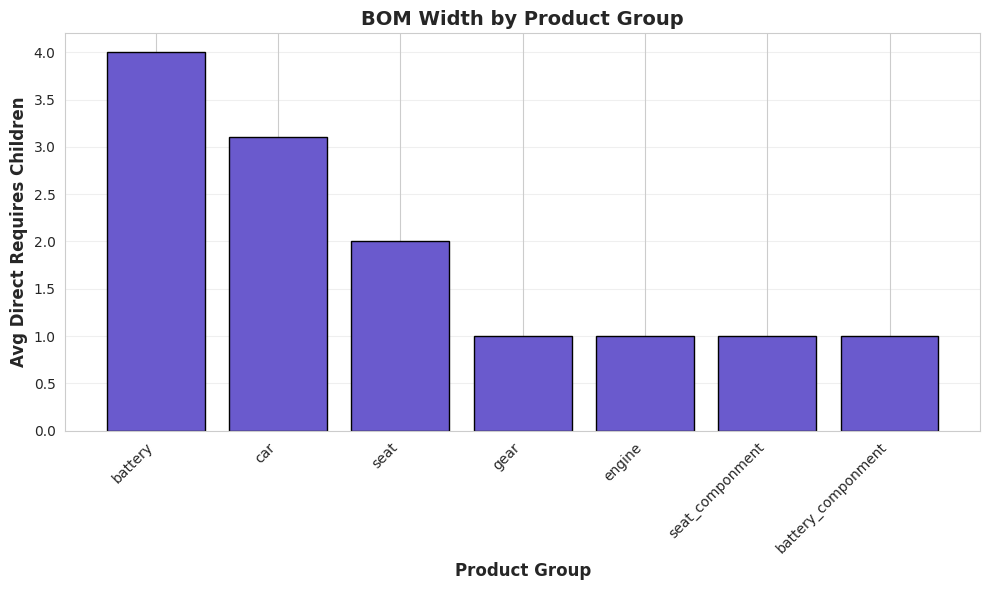

In [12]:


eda_2_cypher = """
MATCH (pg:ProductGroup)<-[:BELONGS_TO]-(p:Product)
OPTIONAL MATCH (p)-[r:REQUIRES]->(:Product)
WITH pg, p, count(r) AS nChildren
RETURN pg.groupName AS groupName,
 count(p) AS nProducts,
 avg(toFloat(nChildren)) AS avgRequiresChildren,
 max(nChildren) AS maxRequiresChildren
ORDER BY nProducts DESC
"""

eda2 = run_query(eda_2_cypher)


display(eda2)

if not eda2.empty:
    import matplotlib.pyplot as plt

    eda2_plot = eda2.copy()
    eda2_plot["groupName"] = eda2_plot["groupName"].fillna("Unknown").astype(str).str.strip()
    eda2_plot.loc[eda2_plot["groupName"] == "", "groupName"] = "Unknown"

    # Sort so the tallest bars appear first
    eda2_plot = eda2_plot.sort_values("avgRequiresChildren", ascending=False).reset_index(drop=True)

    plt.figure(figsize=(10, 6))
    plt.bar(
        eda2_plot["groupName"],
        eda2_plot["avgRequiresChildren"],
        color="slateblue",
        edgecolor="black",
    )
    plt.xlabel("Product Group", fontsize=12, fontweight="bold")
    plt.ylabel("Avg Direct Requires Children", fontsize=12, fontweight="bold")
    plt.title("BOM Width by Product Group", fontsize=14, fontweight="bold")
    plt.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


### EDA 3: Which products have the largest direct tier-1 fan-out in this graph?

**Query logic:** For every `Product`, optionally resolve its `ProductGroup` via `BELONGS_TO`, count outgoing `REQUIRES` relationships (`count(rq)`) as `nDirectComponents`, then return `productId`, `groupName`, and `nDirectComponents`. Results are ordered by descending fan-out (then `productId`) and limited to the top 5 products.

**Explanation:** This query identifies the parent SKUs with the widest one-hop BOM breadth (most direct component dependencies). These products are useful starting points for local disruption and substitution analysis because each parent directly depends on more immediate component links.

**Interpretation of results:**
- The top-5 products by direct `REQUIRES` fan-out are all car-group SKUs, and each has **4** direct components (`64002`, `64099`, `64184`, `64185`, `64354`).
- Since all top entries are tied at 4, this section indicates a shared upper tier of direct BOM breadth rather than a single dominant outlier SKU.
- Immediate BOM complexity is concentrated in a small set of finished-car products; these are natural candidates for first-pass dependency stress checks.

---


In [13]:


eda_3_cypher = """
MATCH (p:Product)
OPTIONAL MATCH (p)-[:BELONGS_TO]->(pg:ProductGroup)
OPTIONAL MATCH (p)-[rq:REQUIRES]->()
WITH p, coalesce(pg.groupName, 'Unknown') AS groupName, count(rq) AS nDirectComponents
RETURN p.productId AS productId, groupName, nDirectComponents
ORDER BY nDirectComponents DESC, p.productId ASC
LIMIT 5
"""
display(run_query(eda_3_cypher))



,productId,groupName,nDirectComponents
0,64002,car,4
1,64099,car,4
2,64184,car,4
3,64185,car,4
4,64354,car,4


### EDA 4: How many direct components does each car product require, by component group?

**Query logic:** Match finished vehicles (`Product` in `ProductGroup {groupName: 'car'}`), traverse tier-1 `(car)-[:REQUIRES]->(child:Product)`, and require each child to map to a `ProductGroup`. Return per-car counts (`carID`, `childGroup`, `directComponents`), then aggregate in pandas to get total `nRequiresEdges` by `childGroup` for the summary table and bar chart.

**Explanation:** This shows how tier-1 BOM dependencies are distributed across component families for the vehicle portfolio. It separates platform-common dependencies from configuration-specific dependencies that affect only selected variants.

**Interpretation of results:**
- **`engine`**, **`gear`**, and **`seat`** each register **28,000** tier-1 edges, matching the full car SKU count in this extract. These behave as platform-common dependencies with broad assembly impact if constrained.
- **`battery`** has **3,003** tier-1 edges, far below 28,000, so battery appears as a direct dependency for only a subset of vehicle variants.
- This aligns with the notebook guardrail that battery is **variant-specific** in this modeled portfolio rather than universal across all car SKUs.
- Protect common-component continuity (`engine/gear/seat`) for portfolio-wide throughput, and handle battery exposure with targeted variant-level sourcing and lane planning.

---


,childGroup,nRequiresEdges
1,engine,28000
2,gear,28000
3,seat,28000
0,battery,3003


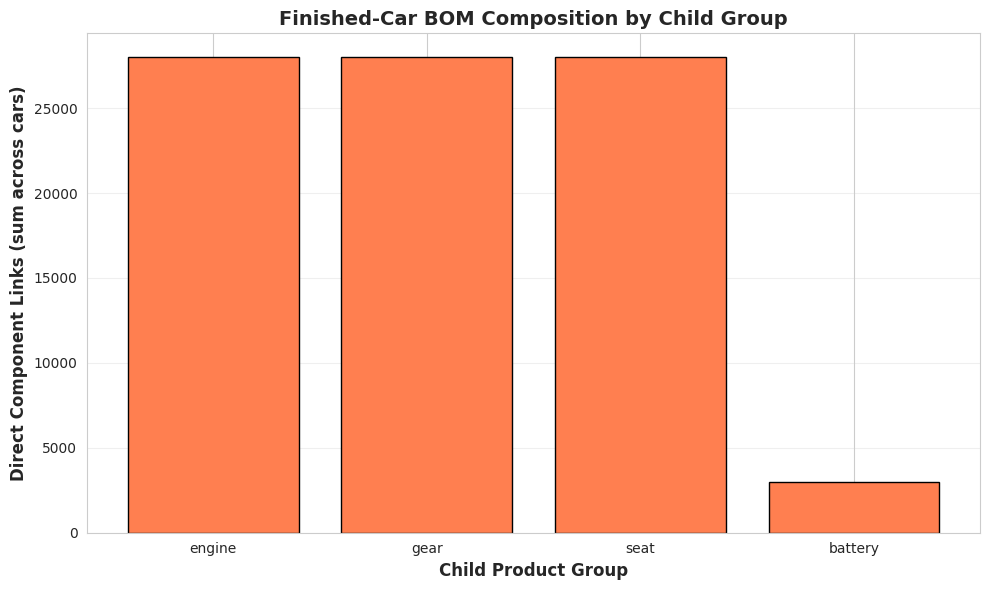

In [14]:
eda_4_cypher = """
MATCH (car:Product)-[:BELONGS_TO]->(:ProductGroup {groupName: 'car'})
MATCH (car)-[rq:REQUIRES]->(child:Product)-[:BELONGS_TO]->(g:ProductGroup)
WITH car.productId AS carID,
     g.groupName AS childGroup,
     count(rq) AS directComponents
RETURN carID, childGroup, directComponents
ORDER BY carID, directComponents DESC
"""

eda4 = run_query(eda_4_cypher)

if not eda4.empty:
    eda4_summary = (
        eda4.groupby("childGroup", as_index=False)["directComponents"]
        .sum()
        .rename(columns={"directComponents": "nRequiresEdges"})
        .sort_values("nRequiresEdges", ascending=False)
    )

    display(eda4_summary)

    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 6))
    plt.bar(
        eda4_summary["childGroup"],
        eda4_summary["nRequiresEdges"],
        color="coral",
        edgecolor="black",
    )
    plt.xlabel("Child Product Group", fontsize=12, fontweight="bold")
    plt.ylabel("Direct Component Links (sum across cars)", fontsize=12, fontweight="bold")
    plt.title("Finished-Car BOM Composition by Child Group", fontsize=14, fontweight="bold")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


### EDA 5: Which directed lanes carry the highest logistics time cost in the sparse facility network?

**Query logic:** Match all directed logistics edges `(:Facility)-[:SHIPS_TO]->(:Facility)` and return lane identity plus timing metadata: `fromNode`, `toNode`, `arcKey`, `productGroup`, and `leadTime`. Sort descending by `leadTime` . In pandas, coerce `leadTime` to numeric, build a display key (`arcKey`, with `from->to` fallback if needed), then plot the highest-lead-time lanes.

**Explanation:** This is a structural baseline for logistics delay risk. In this sparse facility graph, many nodes have similar degree patterns, so lane-specific `leadTime` is the clearest first discriminator of schedule sensitivity. This section intentionally ranks lanes by intrinsic transit/process delay and does not include period-specific capacity/flow pressure.

**Interpretation of results:**
- Highest-delay lanes are upstream transport-to-production links: `seat-supplier_trans -> seat-supplier_prod` (**23**) and `battery-supplier_trans -> battery-supplier_prod` (**20**), well above the rest.
- Mid/low-delay lanes cluster at **2**, **1**, and **0** lead-time units (e.g., gear links at **2**; several battery/engine links at **1**; seat and `zp7 -> zp8` at **0**).
- The lane-delay profile is sharply skewed: a small number of lanes dominate structural time cost while most lanes are short.

---


,fromNode,toNode,arcKey,productGroup,leadTime
0,seat-supplier_trans,seat-supplier_prod,seat-supplier_trans|seat-supplier_prod,seat_componment,23
1,battery-supplier_trans,battery-supplier_prod,battery-supplier_trans|battery-supplier_prod,battery_componment,20
2,gear-supplier_inv,zp7,gear-supplier_inv|zp7,gear,2
3,gear-supplier_prod,gear-supplier_inv,gear-supplier_prod|gear-supplier_inv,gear,2
4,battery-supplier_inv,zp7,battery-supplier_inv|zp7,battery,1
5,battery-supplier_prod,battery-supplier_inv,battery-supplier_prod|battery-supplier_inv,battery,1
6,engine-supplier_inv,zp7,engine-supplier_inv|zp7,engine,1
7,engine-supplier_prod,engine-supplier_inv,engine-supplier_prod|engine-supplier_inv,engine,1
8,seat-supplier_inv,zp7,seat-supplier_inv|zp7,seat,0
9,seat-supplier_prod,seat-supplier_inv,seat-supplier_prod|seat-supplier_inv,seat,0


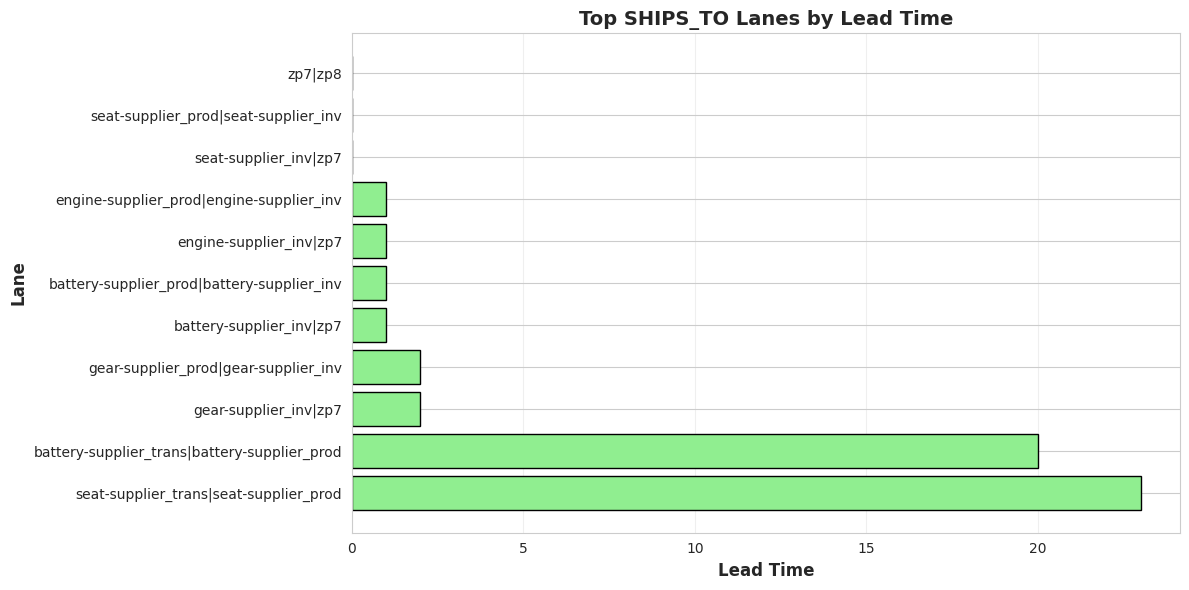

In [15]:


eda_5_lane_catalog = """
MATCH (a:Facility)-[s:SHIPS_TO]->(b:Facility)
RETURN a.nodeId AS fromNode,
 b.nodeId AS toNode,
 s.arcKey AS arcKey,
 s.productGroup AS productGroup,
 s.leadTime AS leadTime
ORDER BY leadTime DESC, fromNode, toNode
"""

eda5_lanes = run_query(eda_5_lane_catalog)
display(eda5_lanes)

# Visualize top lanes by lead time.
if not eda5_lanes.empty:
    top_lanes = eda5_lanes.copy()
    top_lanes["leadTime"] = pd.to_numeric(top_lanes["leadTime"], errors="coerce")

    # arcKey should exist in the dataset; fall back to from/to if needed.
    top_lanes["laneKey"] = top_lanes.get("arcKey")
    if top_lanes["laneKey"].isna().any():
        top_lanes.loc[top_lanes["laneKey"].isna(), "laneKey"] = (
            top_lanes["fromNode"].astype(str) + "->" + top_lanes["toNode"].astype(str)
        )

    top_lanes = top_lanes.dropna(subset=["leadTime"]).sort_values("leadTime", ascending=False).head(15)

    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 6))
    plt.barh(top_lanes["laneKey"], top_lanes["leadTime"], color="lightgreen", edgecolor="black")
    plt.xlabel("Lead Time", fontsize=12, fontweight="bold")
    plt.ylabel("Lane", fontsize=12, fontweight="bold")
    plt.title("Top SHIPS_TO Lanes by Lead Time", fontsize=14, fontweight="bold")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

### EDA 6: How are demand periods, opening-state periods, and in-transit initial-flow periods aligned in this dataset?

**Query logic:** Build one period-range table by unioning five layers and summarizing each with `min(periodId)`, `max(periodId)`, `count(DISTINCT periodId)`, and record count: (1) `DemandFact-[:IN_PERIOD]->Period`, (2) `HOLDS`, (3) `INITIAL_FLOW_TO`, (4) `CAPACITY_AT`, and (5) `PLANNED_FLOW_TO`.

**Explanation:** This checks timeline semantics across demand, opening inventory, in-transit initialization, and planning/constraint layers. Without period alignment, shortage and bottleneck interpretations can mix pre-horizon initialization with in-horizon demand behavior.

**Interpretation of results:**
- Demand horizon is exactly `61..74` with 14 periods (`DemandFact/IN_PERIOD`).
- Opening inventory is a single snapshot at `t=60` (`HOLDS`).
- Initial in-transit flow start periods are pre-horizon (`39..60`) (`INITIAL_FLOW_TO`).
- Capacity spans the full demand horizon (`CAPACITY_AT = 61..74`).
- Product-level planned flow covers a shorter window (`PLANNED_FLOW_TO = 61..70`).

---


,layer,minPeriod,maxPeriod,nPeriods,nRecords
0,DemandFact/IN_PERIOD,61,74,14,28000
1,HOLDS (opening inventory),60,60,1,82
2,INITIAL_FLOW_TO (start periods),39,60,5,117
3,CAPACITY_AT,61,74,14,154
4,PLANNED_FLOW_TO,61,70,10,365


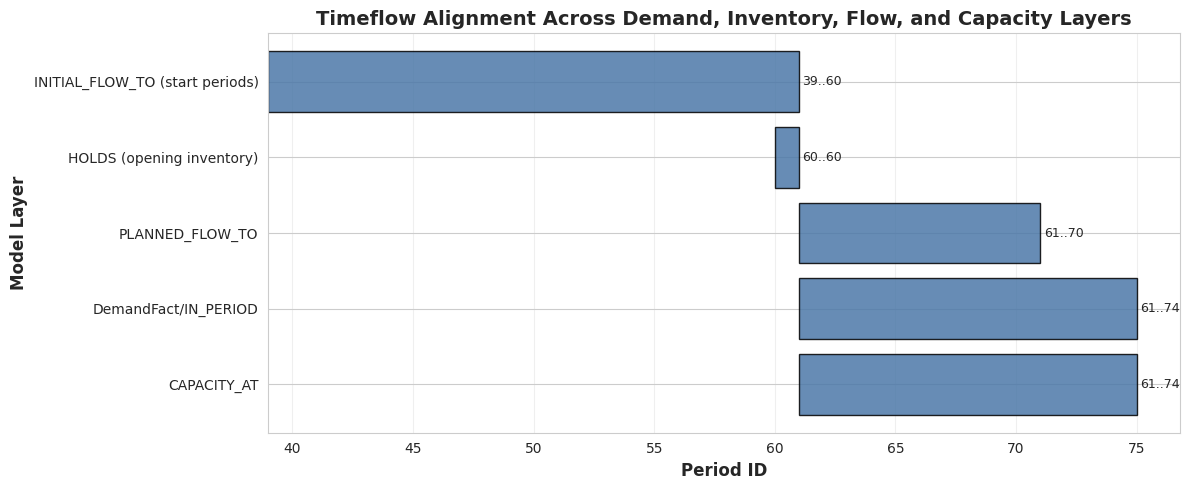

In [16]:


eda_6_period_ranges = """
MATCH (f:DemandFact)-[:IN_PERIOD]->(t:Period)
RETURN 'DemandFact/IN_PERIOD' AS layer,
 min(t.periodId) AS minPeriod,
 max(t.periodId) AS maxPeriod,
 count(DISTINCT t.periodId) AS nPeriods,
 count(f) AS nRecords
UNION ALL
MATCH ()-[h:HOLDS]->()
RETURN 'HOLDS (opening inventory)' AS layer,
 min(h.periodId) AS minPeriod,
 max(h.periodId) AS maxPeriod,
 count(DISTINCT h.periodId) AS nPeriods,
 count(h) AS nRecords
UNION ALL
MATCH ()-[x:INITIAL_FLOW_TO]->()
RETURN 'INITIAL_FLOW_TO (start periods)' AS layer,
 min(x.periodId) AS minPeriod,
 max(x.periodId) AS maxPeriod,
 count(DISTINCT x.periodId) AS nPeriods,
 count(x) AS nRecords
UNION ALL
MATCH ()-[c:CAPACITY_AT]->()
RETURN 'CAPACITY_AT' AS layer,
 min(c.periodId) AS minPeriod,
 max(c.periodId) AS maxPeriod,
 count(DISTINCT c.periodId) AS nPeriods,
 count(c) AS nRecords
UNION ALL
MATCH ()-[p:PLANNED_FLOW_TO]->()
RETURN 'PLANNED_FLOW_TO' AS layer,
 min(p.periodId) AS minPeriod,
 max(p.periodId) AS maxPeriod,
 count(DISTINCT p.periodId) AS nPeriods,
 count(p) AS nRecords
ORDER BY layer
"""
display(run_query(eda_6_period_ranges))


# Assume df_ranges is the DataFrame returned by run_query(eda_6_period_ranges)
df_ranges = run_query(eda_6_period_ranges)

if not df_ranges.empty:
    import pandas as pd
    import matplotlib.pyplot as plt

    df = df_ranges.copy()
    df["minPeriod"] = pd.to_numeric(df["minPeriod"], errors="coerce")
    df["maxPeriod"] = pd.to_numeric(df["maxPeriod"], errors="coerce")
    df = df.dropna(subset=["minPeriod", "maxPeriod"]).reset_index(drop=True)

    # Duration in period units (inclusive)
    df["duration"] = (df["maxPeriod"] - df["minPeriod"] + 1).clip(lower=0)

    # Force analytical display order for timeline reading.
    layer_order = [
        "INITIAL_FLOW_TO (start periods)",
        "HOLDS (opening inventory)",
        "PLANNED_FLOW_TO",
        "DemandFact/IN_PERIOD",
        "CAPACITY_AT",
    ]
    df["layer"] = pd.Categorical(df["layer"], categories=layer_order, ordered=True)
    df = df.sort_values(["layer", "minPeriod", "maxPeriod"]).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(12, 5))

    y = range(len(df))
    ax.barh(
        y,
        df["duration"],
        left=df["minPeriod"],
        color="#4C78A8",
        edgecolor="black",
        alpha=0.85
    )

    # Put first ordered layer at the top (not the bottom).
    ax.invert_yaxis()

    ax.set_yticks(list(y))
    ax.set_yticklabels(df["layer"])
    ax.set_xlabel("Period ID", fontsize=12, fontweight="bold")
    ax.set_ylabel("Model Layer", fontsize=12, fontweight="bold")
    ax.set_title("Timeflow Alignment Across Demand, Inventory, Flow, and Capacity Layers",
                 fontsize=14, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)

    # Label each bar with min..max
    for i, row in df.iterrows():
        ax.text(
            row["minPeriod"] + row["duration"] + 0.15,
            i,
            f"{int(row['minPeriod'])}..{int(row['maxPeriod'])}",
            va="center",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

### EDA 7: Which lanes show the tightest capacity at the start of the demand horizon (`t=61`)?

**Query logic:** Join `SHIPS_TO` with `CAPACITY_AT` on matching endpoints and `arcKey`, filter to `periodId = 61`, and return lane identity (`arcKey`, from/to node), `leadTime`, shipped product group, and capacity. Sort ascending by `capacity` to surface the tightest lanes first.

**Explanation:** This checks which shipping lanes are already tight at the very start of the timeline.If a lane is tight early, it can cause delivery problems quickly.So this gives us a simple starting picture of lane limits before we do deeper analysis across many time periods.

**Interpretation of results :**

- The **smallest capacities are `294`** on the battery legs `battery-supplier_inv → zp7` and `battery-supplier_prod → battery-supplier_inv` (both with **`leadTime = 1`**). That makes the **battery sub-chain the lowest-throughput bucket** , meaning any sustained battery movement is **more likely to hit a capacity ceiling sooner** than the large `2100`-scale supplier corridors.

- The inbound supplier-to-hub pattern for **seat / gear / engine** is **highly uniform**: each shown leg has **`capacity = 2100`**, with small lead times (`0–2`). This reads like a **deliberately symmetric “bulk inbound” design** into `zp7`, where differences in operational stress will mostly come from **flows and mix**, not from differentiated per-lane capacity at this horizon slice.

- The finished-goods lane **`zp7 → zp8`** sits in the middle at **`capacity = 2000`** with **`leadTime = 0`** for `car`. Interpreting across groups: it is **much larger than battery’s `294` lanes**, but **slightly below the `2100` supplier-to-hub standard**, which is consistent with modeling **high outbound finished-goods throughput** without matching the maximum inbound corridor capacity tier.


---


In [17]:

EDA_7_PERIOD_ID = 61

eda_7_capacity = f"""
MATCH (a:Facility)-[s:SHIPS_TO]->(b:Facility)
MATCH (a)-[c:CAPACITY_AT]->(b)
WHERE c.periodId = {EDA_7_PERIOD_ID} AND s.arcKey = c.arcKey AND c.capacity > 0
RETURN s.arcKey AS arcKey,
       a.nodeId AS fromNode,
       b.nodeId AS toNode,
       s.leadTime AS leadTime,
       s.productGroup AS shipsProductGroup,
       c.capacity AS capacity
ORDER BY c.capacity ASC
"""
display(run_query(eda_7_capacity))


,arcKey,fromNode,toNode,leadTime,shipsProductGroup,capacity
0,battery-supplier_inv|zp7,battery-supplier_inv,zp7,1,battery,294
1,battery-supplier_prod|battery-supplier_inv,battery-supplier_prod,battery-supplier_inv,1,battery,294
2,zp7|zp8,zp7,zp8,0,car,2000
3,seat-supplier_inv|zp7,seat-supplier_inv,zp7,0,seat,2100
4,gear-supplier_inv|zp7,gear-supplier_inv,zp7,2,gear,2100
5,engine-supplier_inv|zp7,engine-supplier_inv,zp7,1,engine,2100
6,seat-supplier_prod|seat-supplier_inv,seat-supplier_prod,seat-supplier_inv,0,seat,2100
7,gear-supplier_prod|gear-supplier_inv,gear-supplier_prod,gear-supplier_inv,2,gear,2100
8,engine-supplier_prod|engine-supplier_inv,engine-supplier_prod,engine-supplier_inv,1,engine,2100


### EDA 8: How is opening inventory (`HOLDS`) concentrated across facilities?

**Query logic:** Aggregate `HOLDS.initialInventory` by facility and count hold relationships per node (`holdRels`). Return node id, labels, total opening inventory, and relationship count sorted by highest opening inventory.

**Explanation:** Opening inventory is the initial shock absorber. Concentration tells us where buffer power is strongest (or weakest) at the start of the planning horizon.

**Interpretation of results:**
- Opening inventory is **heavily concentrated in a small set of facilities**. In the returned ranking, `zp7` (labeled `OEM`) holds **`totalInitialInv = 6052`** across **`holdRels = 38`** distinct `HOLDS` edges, which reads as a **broad hub buffer**: substantial opening stock is spread across many product holdings at the central OEM node.

- The next-largest buffers are **large but structurally different**:
  - `seat-supplier_prod` shows **`6000`** opening inventory but only **`holdRels = 4`**, implying **very concentrated holdings** (few products carry most of the opening stock at that production site).
  - `engine-supplier_inv` also shows **`6000`**, but with **`holdRels = 29`**, implying **more distributed inventory** across many product lines at the inventory site.

- `gear-supplier_inv` is mid-tier (**`4000`**, **`holdRels = 8`**), while `battery-supplier_prod` is materially smaller (**`1860`**, **`holdRels = 3`**), again suggesting **concentrated** opening stock at production.

- The network begins with **a dominant OEM-side buffer (`zp7`)** plus **two very large upstream buffers tied to seat production and engine inventory**, with **battery production starting materially lighter** on opening inventory in this ranking window. This matters because **high `totalInitialInv` reduces early-period stockout risk**, while **low `holdRels` concentration** can mean **single-SKU fragility** if the few stocked products are the ones under demand pressure.

---


In [18]:

eda_8_holds = """
MATCH (n:Facility)-[h:HOLDS]->(:Product)
WITH n, sum(h.initialInventory) AS totalInitialInv, count(h) AS holdRels
RETURN n.nodeId AS nodeId, labels(n) AS labels, totalInitialInv, holdRels
ORDER BY totalInitialInv DESC
"""
display(run_query(eda_8_holds))


,nodeId,labels,totalInitialInv,holdRels
0,zp7,"[OEM, Facility]",6052,38
1,seat-supplier_prod,"[SupplierSite, Production, Facility]",6000,4
2,engine-supplier_inv,"[SupplierSite, Inventory, Facility]",6000,29
3,gear-supplier_inv,"[SupplierSite, Inventory, Facility]",4000,8
4,battery-supplier_prod,"[SupplierSite, Production, Facility]",1860,3


### EDA 9: Which corridors carry the largest initial in-transit flow?

**Query logic:** Sum `INITIAL_FLOW_TO.initialFlow` by lane (`arcKey`, from/to facility). Return ranked corridors by descending total initial flow and limit to the top lanes.

**Explanation:** Initial in-transit flow concentration reveals corridor dependence at horizon start. Large concentration on few lanes indicates potential fragility if those corridors are disrupted.

**Interpretation of results:**
- Initial in-transit volume is **extremely concentrated on two supplier production ingress corridors**. The largest lane is **`seat-supplier_trans → seat-supplier_prod`** with **`sumInitialFlow = 56,000`** on arcKey `seat-supplier_trans|seat-supplier_prod`, followed by **`battery-supplier_trans → battery-supplier_prod`** with **`35,860`** on `battery-supplier_trans|battery-supplier_prod`. Together these two arcs dominate the displayed ranking, which implies **early pipeline exposure** is driven primarily by **inbound component logistics into seat and battery production**, not by a diffuse set of lanes.

- The next tier is **an order of magnitude smaller** and looks like **balanced “inv → hub” and “prod → inv” pairs** for gear and engine:
  - Gear shows **`4,000`** on both `gear-supplier_inv → zp7` and `gear-supplier_prod → gear-supplier_inv`.
  - Engine shows **`2,000`** on both `engine-supplier_inv → zp7` and `engine-supplier_prod → engine-supplier_inv`.
  This symmetry is consistent with **coherent upstream staging**: similar totals on adjacent legs suggest the initial pipeline is modeled as **internally consistent** across production/inventory/hub hops for those chains (at least at the aggregate lane level returned here).

- Battery beyond the dominant trans→prod leg is comparatively small in this window: **`battery-supplier_inv → zp7` is `200`** and **`battery-supplier_prod → battery-supplier_inv` is `159`**. So battery’s **starting in-transit story is heavily skewed to the trans→prod corridor**, with comparatively modest remaining initial pipeline on the later hops shown.


---


In [19]:

eda_9_init_flow = """
MATCH (a:Facility)-[x:INITIAL_FLOW_TO]->(b:Facility)
WITH a.nodeId AS fromNode, b.nodeId AS toNode, x.arcKey AS arcKey, sum(x.initialFlow) AS sumInitialFlow
RETURN fromNode, toNode, arcKey, sumInitialFlow
ORDER BY sumInitialFlow DESC
LIMIT 20
"""
display(run_query(eda_9_init_flow))


,fromNode,toNode,arcKey,sumInitialFlow
0,seat-supplier_trans,seat-supplier_prod,seat-supplier_trans|seat-supplier_prod,56000
1,battery-supplier_trans,battery-supplier_prod,battery-supplier_trans|battery-supplier_prod,35860
2,gear-supplier_inv,zp7,gear-supplier_inv|zp7,4000
3,gear-supplier_prod,gear-supplier_inv,gear-supplier_prod|gear-supplier_inv,4000
4,engine-supplier_inv,zp7,engine-supplier_inv|zp7,2000
5,engine-supplier_prod,engine-supplier_inv,engine-supplier_prod|engine-supplier_inv,2000
6,battery-supplier_inv,zp7,battery-supplier_inv|zp7,200
7,battery-supplier_prod,battery-supplier_inv,battery-supplier_prod|battery-supplier_inv,159


### EDA 10: Which components are used across the largest share of finished car products?

**Query logic:** Collect all finished `car` products to compute the denominator (`totalCars`), then traverse variable-length BOM dependencies `(car)-[:REQUIRES*1..]->(comp)` and aggregate by component. For each component, return: (1) number of distinct cars that depend on it (`nCarProductsUsingComponent`), (2) portfolio coverage percentage (`pctOfCarPortfolio`), and (3) number of distinct dependency paths (`nDependencyPaths`). Rank by highest car coverage.

**Explanation:** This measures dependency spread risk. Components used by a large fraction of car products represent systemic concentration points: disruption at these components can propagate across many finished vehicles at once.

**Interpretation of results:**
- The highest-coverage components in this run are `componment_seat2` and `Q4H`, each used by **12,038 cars** (**42.99%** of the car portfolio).
- `componment_seat1` and `Q2J` follow at **9,726 cars** (**34.74%**), and `G0K` appears in **8,592 cars** (**30.69%**).
- Coverage then drops to `G1C` (**23.8%**), `G1D` (**15.04%**), `componment_seat3` and `Q4P` (**13.65%**), and `DN4` (**13.25%**).
- `nDependencyPaths` is substantially larger than car counts for some components (for example `componment_seat2` with **48,152** paths), indicating repeated/embedded dependency routes rather than a single shallow linkage.
- Seat-related and select coded components are broad-impact dependencies. They are prime targets for resilience actions (alternate sourcing, buffer policy, and continuity monitoring).

---


,componentId,componentGroup,nCarProductsUsingComponent,pctOfCarPortfolio,nDependencyPaths
0,componment_seat2,seat_componment,12038,42.99,48152
1,Q4H,seat,12038,42.99,24076
2,componment_seat1,seat_componment,9726,34.74,38904
3,Q2J,seat,9726,34.74,19452
4,G0K,gear,8592,30.69,17184
5,G1C,gear,6664,23.80,13328
6,G1D,gear,4210,15.04,8420
7,componment_seat3,seat_componment,3823,13.65,15292
8,Q4P,seat,3823,13.65,7646
9,DN4,engine,3710,13.25,7420


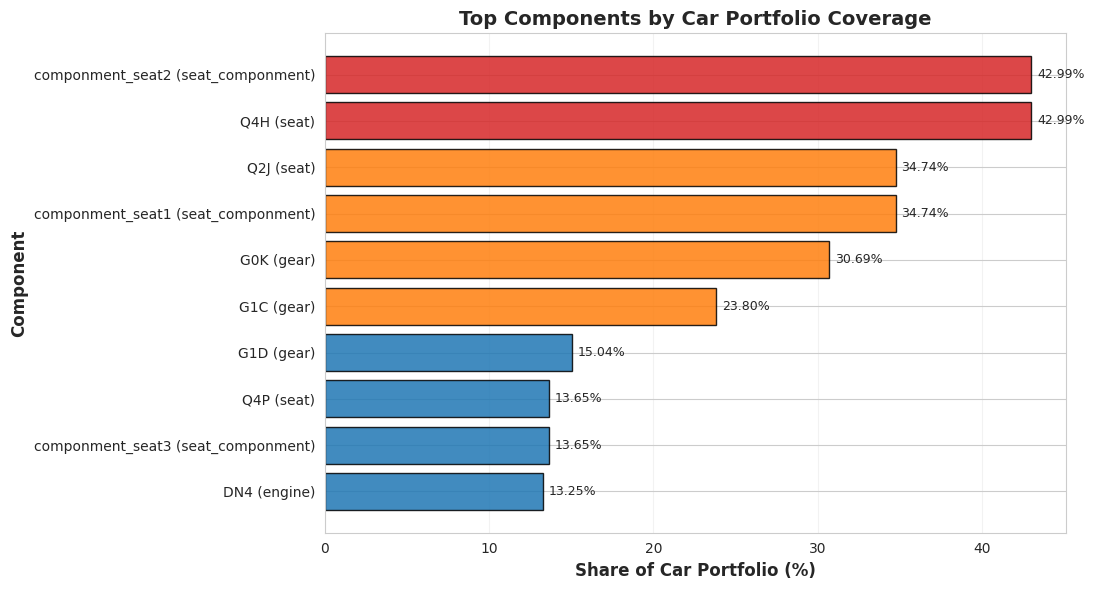

In [20]:
eda_10_component_spread = """
MATCH (car:Product)-[:BELONGS_TO]->(:ProductGroup {groupName:'car'})
WITH collect(DISTINCT car) AS cars, count(DISTINCT car) AS totalCars
UNWIND cars AS car
MATCH p = (car)-[:REQUIRES*1..]->(comp:Product)
WHERE comp <> car
OPTIONAL MATCH (comp)-[:BELONGS_TO]->(cg:ProductGroup)
WITH
  comp,
  cg,
  totalCars,
  collect(DISTINCT car) AS dependentCars,
  count(DISTINCT p) AS nDependencyPaths
RETURN
  comp.productId AS componentId,
  coalesce(cg.groupName, 'unassigned') AS componentGroup,
  size(dependentCars) AS nCarProductsUsingComponent,
  round(100.0 * size(dependentCars) / totalCars, 2) AS pctOfCarPortfolio,
  nDependencyPaths
ORDER BY nCarProductsUsingComponent DESC, nDependencyPaths DESC
LIMIT 10
"""

eda10 = run_query(eda_10_component_spread)
display(eda10)

if not eda10.empty:
    import matplotlib.pyplot as plt

    eda10_plot = eda10.sort_values("pctOfCarPortfolio", ascending=True).copy()
    eda10_plot["componentLabel"] = (
        eda10_plot["componentId"] + " (" + eda10_plot["componentGroup"] + ")"
    )

    def risk_color(pct):
        if pct > 35:
            return "#d62728"  # red: high systemic coverage risk
        if pct >= 20:
            return "#ff7f0e"  # orange: medium risk
        return "#1f77b4"      # blue: lower risk

    colors = [risk_color(pct) for pct in eda10_plot["pctOfCarPortfolio"]]

    plt.figure(figsize=(11, 6))
    bars = plt.barh(
        eda10_plot["componentLabel"],
        eda10_plot["pctOfCarPortfolio"],
        color=colors,
        edgecolor="black",
        alpha=0.85,
    )

    for bar, pct in zip(bars, eda10_plot["pctOfCarPortfolio"]):
        plt.text(
            bar.get_width() + 0.35,
            bar.get_y() + bar.get_height() / 2,
            f"{pct:.2f}%",
            va="center",
            fontsize=9,
        )

    plt.xlabel("Share of Car Portfolio (%)", fontsize=12, fontweight="bold")
    plt.ylabel("Component", fontsize=12, fontweight="bold")
    plt.title("Top Components by Car Portfolio Coverage", fontsize=14, fontweight="bold")
    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


---

## 7. Deeper analytical questions

Having characterized the network through exploratory analysis, we now address three strategic questions that require advanced graph traversal and aggregation.


### 7.1 Analytical Question 1: Component Concentration Risk Map

**Business Question:** Which components and part families create the largest assembly blast radius across vehicle SKUs if disrupted?

**Operational Context:**

Automotive BOM risk is often concentrated in a small set of high-commonality parts. A disruption in one highly reused component can propagate across multiple vehicle programs, while low-commonality parts create localized impact. Component-level concentration is especially useful when finished-SKU metrics are weakly discriminative.

**Query Logic:**

This query maps concentration at component level:

1. Traverse transitive BOM edges `(:Product)-[:REQUIRES*1..]->(:Product)`
2. Treat each downstream endpoint as a candidate risk component
3. Count distinct upstream products that depend on each component (`upstreamProductsDependingOnIt`)
4. Count total dependency paths reaching each component (`totalDependencyPaths`)
5. Attach `ProductGroup` and rank components by concentration

This produces a structural risk map that highlights where parts-commonality concentration is most severe.


In [21]:
# Component concentration risk map across full BOM
analytical1 = run_query("""
MATCH (parent:Product)-[:REQUIRES*1..]->(comp:Product)
WHERE parent <> comp
OPTIONAL MATCH (comp)-[:BELONGS_TO]->(g:ProductGroup)
RETURN
  comp.productId AS componentId,
  coalesce(g.groupName, 'unassigned') AS componentGroup,
  count(DISTINCT parent) AS upstreamProductsDependingOnIt,
  count(*) AS totalDependencyPaths
ORDER BY upstreamProductsDependingOnIt DESC, totalDependencyPaths DESC
LIMIT 10
""")

print("Component Concentration Risk Map")
print("=" * 60)
display(analytical1)

Component Concentration Risk Map


,componentId,componentGroup,upstreamProductsDependingOnIt,totalDependencyPaths
0,componment_seat2,seat_componment,12039,48156
1,Q4H,seat,12038,24076
2,componment_seat1,seat_componment,9727,38908
3,Q2J,seat,9726,19452
4,G0K,gear,8592,17184
5,G1C,gear,6664,13328
6,G1D,gear,4210,8420
7,componment_seat3,seat_componment,3824,15296
8,Q4P,seat,3823,7646
9,DN4,engine,3710,7420



**Results Interpretation:**

The top-10 is highly concentrated in seat- and gear-related structures, with additional engine exposure:

- `componment_seat2` (`seat_componment`) is the largest hub (**12,039 upstream products**, **48,156 dependency paths**)
- `Q4H` (`seat`) follows at (**12,038**, **24,076**)
- `componment_seat1` (`seat_componment`) and `Q2J` (`seat`) remain very high (about **9.7k** upstream products each)
- Gear components (`G0K`, `G1C`, `G1D`) and engine component `DN4` also appear in the top-10 but below seat hubs

This pattern indicates concentration is not uniformly distributed across groups; it is dominated by a few seat/seat-component nodes with large reuse breadth across vehicle SKUs.

**Operational Impact:**

Because the highest-ranked components are shared so broadly, disruption in these nodes can create rapid multi-program shock propagation. The large gap between top seat hubs and lower-ranked components suggests a tiered risk profile: a small subset of parts likely drives most structural BOM fragility.

**Strategic Recommendations:**

1. **Immediate focus parts:** prioritize resilience actions on `componment_seat2`, `Q4H`, `componment_seat1`, and `Q2J` first
2. **Cluster-level mitigation:** treat `seat` + `seat_componment` as a concentrated risk cluster for dual-sourcing and continuity planning
3. **Targeted buffer policy:** place safety stock on top concentration hubs rather than spreading inventory uniformly
4. **Supplier governance:** increase monitoring and contingency depth for facilities producing top-ranked hub components
5. **Engineering review:** evaluate whether extreme reuse in top seat components can be reduced in future BOM revisions


### 7.2 Analytical Question 2: Arc Structural Fragility (Lead Time + Capacity + Buffer)

**Business Question:** Which logistics arcs are structurally fragile based on long lead times, low installed capacity across the demand horizon, and weak destination opening inventory buffers?

**Operational Context:**

In this dataset, product-level planned flow is sparsely populated on only a few arcs, which limits the discriminatory value of utilization-based bottleneck scoring. A more robust lane-risk view is to combine attributes that are available consistently across the network: transit/process delay (`leadTime`), installed arc capacity (`CAPACITY_AT` over periods 61–74), and destination opening inventory (`HOLDS {periodId:60}`).

**Query Logic:**

This query builds a structural fragility score for each `SHIPS_TO` arc:

1. Use `SHIPS_TO.leadTime` as delay risk baseline
2. Aggregate arc capacity over the demand horizon (`periodId 61..74`), keeping minimum and average capacity plus coverage count
3. Sum destination opening inventory at period 60 as a local resilience buffer
4. Compute a composite `structuralFragilityScore` that increases with lead time and decreases with capacity and destination buffer depth
5. Rank arcs by fragility score to identify persistent structural bottlenecks

This formulation avoids over-reliance on sparse planned-flow fields while preserving operational interpretability.

**Weighting rationale for `structuralFragilityScore`:**

We use a policy-weighted composite score to rank persistent lane fragility:
- **Lead time (0.45):** highest weight because long supplier-to-plant delay is the hardest constraint to recover from in near-term production scheduling.
- **Capacity tightness (0.35):** second-highest weight because low installed capacity limits replenishment even when demand and dispatch intent are clear.
- **Destination opening inventory buffer (0.20):** lower (but non-zero) weight because opening stock can absorb short shocks but is finite and quickly depleted.

This is an operations-prioritized heuristic for this dataset (not a causal estimate). The objective is stable comparative ranking of lanes for mitigation sequencing.


In [22]:
# Arc structural fragility score using robustly populated fields
analytical2 = run_query("""
MATCH (a:Facility)-[s:SHIPS_TO]->(b:Facility)
OPTIONAL MATCH (a)-[c:CAPACITY_AT]->(b)
WHERE c.arcKey = s.arcKey AND c.periodId >= 61 AND c.periodId <= 74
WITH a, b, s,
     min(c.capacity) AS minCapacity,
     avg(toFloat(c.capacity)) AS avgCapacity,
     count(c) AS nCapacityPeriods
OPTIONAL MATCH (b)-[h:HOLDS {periodId: 60}]->(:Product)
WITH a, b, s, minCapacity, avgCapacity, nCapacityPeriods,
     sum(coalesce(h.initialInventory, 0)) AS destOpeningInventory
RETURN
  s.arcKey AS arcKey,
  a.nodeId AS fromNode,
  b.nodeId AS toNode,
  coalesce(s.productGroup, 'unknown') AS shipsProductGroup,
  coalesce(s.leadTime, 0) AS leadTime,
  minCapacity,
  round(avgCapacity, 1) AS avgCapacity,
  nCapacityPeriods,
  destOpeningInventory AS destOpeningInventory_t60,
  round(
    0.45 * toFloat(coalesce(s.leadTime, 0)) +
    0.35 * (1.0 / (1.0 + toFloat(coalesce(minCapacity, 0)) / 1000.0)) +
    0.20 * (1.0 / (1.0 + toFloat(coalesce(destOpeningInventory, 0)) / 1000.0))
  , 4) AS structuralFragilityScore
ORDER BY structuralFragilityScore DESC, leadTime DESC, minCapacity ASC
LIMIT 25
""")

print("Arc Structural Fragility Ranking")
print("=" * 60)
display(analytical2)

Arc Structural Fragility Ranking


,arcKey,fromNode,toNode,shipsProductGroup,leadTime,minCapacity,avgCapacity,nCapacityPeriods,destOpeningInventory_t60,structuralFragilityScore
0,seat-supplier_trans|seat-supplier_prod,seat-supplier_trans,seat-supplier_prod,seat_componment,23,0,2100.0,14,6000,10.7286
1,battery-supplier_trans|battery-supplier_prod,battery-supplier_trans,battery-supplier_prod,battery_componment,20,0,294.0,14,1860,9.4199
2,gear-supplier_prod|gear-supplier_inv,gear-supplier_prod,gear-supplier_inv,gear,2,2100,2100.0,14,4000,1.0529
3,gear-supplier_inv|zp7,gear-supplier_inv,zp7,gear,2,2100,2100.0,14,6052,1.0413
4,battery-supplier_prod|battery-supplier_inv,battery-supplier_prod,battery-supplier_inv,battery,1,294,294.0,14,0,0.9205
5,battery-supplier_inv|zp7,battery-supplier_inv,zp7,battery,1,294,294.0,14,6052,0.7488
6,engine-supplier_prod|engine-supplier_inv,engine-supplier_prod,engine-supplier_inv,engine,1,2100,2100.0,14,6000,0.5915
7,engine-supplier_inv|zp7,engine-supplier_inv,zp7,engine,1,2100,2100.0,14,6052,0.5913
8,zp7|zp8,zp7,zp8,car,0,2000,2000.0,14,0,0.3167
9,seat-supplier_prod|seat-supplier_inv,seat-supplier_prod,seat-supplier_inv,seat,0,2100,2100.0,14,0,0.3129


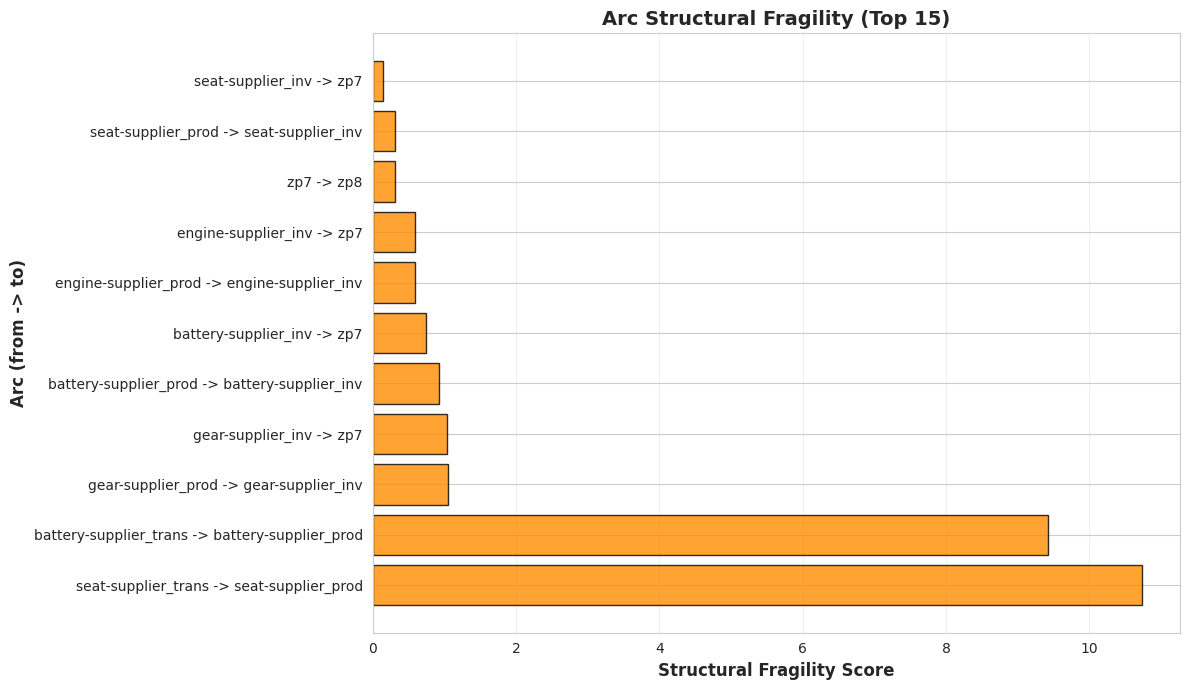

In [23]:
# Visualize arc structural fragility distribution
if not analytical2.empty and len(analytical2) > 5:
 plt.figure(figsize=(12, 7))
 
 # Horizontal bar chart of top 15 most fragile arcs
 top15 = analytical2.head(15).copy()
 top15['arcLabel'] = top15['fromNode'] + ' -> ' + top15['toNode']
 plt.barh(range(len(top15)), top15['structuralFragilityScore'],
 color='darkorange', edgecolor='black', alpha=0.8)
 plt.yticks(range(len(top15)), top15['arcLabel'])
 plt.xlabel('Structural Fragility Score', fontsize=12, fontweight='bold')
 plt.ylabel('Arc (from -> to)', fontsize=12, fontweight='bold')
 plt.title('Arc Structural Fragility (Top 15)',
 fontsize=14, fontweight='bold')
 plt.grid(axis='x', alpha=0.3)
 plt.tight_layout()
 plt.show()

**Results Interpretation:**

The strongest fragility signals are on long-delay supplier ingress arcs feeding production, especially:

- `seat-supplier_trans -> seat-supplier_prod` (`leadTime = 23`) as the top-ranked fragile lane
- `battery-supplier_trans -> battery-supplier_prod` (`leadTime = 20`) as the second-highest fragility lane

Mid-tier fragility appears in gear and battery transfer arcs where lead time is lower but capacities are smaller (notably battery `minCapacity = 294`). Lower-ranked arcs generally combine short lead times with larger capacity and/or stronger destination opening buffers.

**Operational Impact:**

The ranking indicates that delay-heavy supplier ingress corridors are the most structurally sensitive points for assembly continuity. Because this score does not depend on sparse planned-flow records, it provides a stable lane-prioritization baseline for resilience planning under uncertain or incomplete short-term flow plans.

**Strategic Recommendations:**

1. **Ingress contingencies first:** prioritize alternate routing and emergency playbooks for the top two trans->prod arcs (seat and battery)
2. **Battery corridor hardening:** add specific mitigation on low-capacity battery links (`minCapacity = 294`) to reduce saturation risk on battery-equipped variants
3. **Buffer alignment:** increase or reposition destination-side opening buffers for high-fragility lane endpoints
4. **Capacity reinforcement:** evaluate targeted capacity uplift on top-ranked fragile arcs before expanding lower-risk corridors
5. **Ongoing validation:** recompute fragility after capacity or inventory policy changes to confirm risk reduction


### 7.3 Analytical Question 3: Supply Risk-Adjusted Component Priority

**Business Question:** Which components should be prioritized first for mitigation when considering dependency concentration, supplier redundancy, and supplier-lane fragility together?

**Operational Context:**

A component can be structurally central in the BOM yet operationally safer if it has multiple suppliers and robust outbound lanes. Conversely, a part with moderate BOM reach can still be high-priority if it is single-sourced and tied to fragile logistics links. Integrating these dimensions yields a more actionable automotive risk ranking than any single metric alone.

**Query Logic:**

This query computes a component-level priority score by combining three signals:

1. **Dependency concentration:** count distinct upstream products depending on each component via transitive `REQUIRES*`
2. **Supplier redundancy:** count producing facilities via `(:Facility)-[:PRODUCES]->(:Product)`
3. **Supplier-lane fragility:** for each producer, evaluate worst outgoing lane fragility from `SHIPS_TO` lead time and minimum `CAPACITY_AT`; keep the maximum per component

A weighted `riskAdjustedPriorityScore` then ranks components where concentration, single-sourcing, and logistics fragility coincide.

**Weighting rationale for `riskAdjustedPriorityScore`:**

This ranking is designed for mitigation triage, not causal inference. We prioritize three dimensions in descending order:

1. **Dependency blast radius (0.55):** `log10(1 + upstreamProductsDependingOnIt)` receives the largest weight because broad BOM reuse creates the largest potential multi-SKU disruption.
2. **Supplier redundancy risk (0.30):** sourcing structure is the second priority driver.  
   - `supplierCount = 1` is treated as single-source exposure.  
   - `supplierCount > 1` gets decreasing penalty (`1/supplierCount`) to reflect diversification benefit.  
   - `supplierCount = 0` is assigned `1.2` to flag unresolved producer linkage as a high-priority data/risk condition.
3. **Supplier-lane fragility (0.15):** logistics risk is included as an adjustment term so components with similar concentration/redundancy can be separated by delivery vulnerability.

For lane fragility, we weight **lead time (0.6)** above **minimum capacity tightness (0.4)** because long replenishment delay is typically harder to recover from quickly than capacity pressure.

**Interpretation of results:**
- The top risk cluster is concentrated in `seat_componment`: `componment_seat2`, `componment_seat1`, `componment_seat3`, and `componment_seat4` lead the ranking with very high dependency breadth and `supplierCount = 1`.
- `battery_componment` (`componment_battery1/2/3`) forms the second-highest cluster, also single-sourced with high fragility-adjusted scores; this is especially relevant for battery-dependent vehicle variants.
- Gear components (`G0K`, `G1C`) remain important but score lower due to materially smaller supplier-lane fragility.
- `Q4H` appears with very high structural dependence but `supplierCount = 0` and `maxSupplierArcFragility = 0.0`, which signals missing producer linkage in the current graph rather than low risk.

**Operational Implications:**
- Prioritize dual-sourcing and continuity controls first for the seat-component cluster, then the battery-component cluster.
- Treat producer-linkage gaps (for example `Q4H`) as data quality blockers before finalizing mitigation priority lists.
- Use score decomposition (`upstreamProductsDependingOnIt`, `supplierCount`, `maxSupplierArcFragility`) to assign intervention type: sourcing redundancy, lane hardening, or targeted buffering.

---


In [24]:
# Supply risk-adjusted component priority
analytical3 = run_query("""
MATCH (parent:Product)-[:REQUIRES*1..]->(comp:Product)
WHERE parent <> comp
WITH comp, count(DISTINCT parent) AS upstreamProductsDependingOnIt
OPTIONAL MATCH (comp)<-[:PRODUCES]-(prod:Facility)
WITH comp, upstreamProductsDependingOnIt, collect(DISTINCT prod) AS producers
WITH comp, upstreamProductsDependingOnIt, producers, size(producers) AS supplierCount
UNWIND CASE WHEN size(producers)=0 THEN [null] ELSE producers END AS p
OPTIONAL MATCH (p)-[s:SHIPS_TO]->(nxt:Facility)
OPTIONAL MATCH (p)-[c:CAPACITY_AT]->(nxt)
WHERE c.arcKey = s.arcKey AND c.periodId >= 61 AND c.periodId <= 74
WITH
  comp,
  upstreamProductsDependingOnIt,
  supplierCount,
  p,
  s,
  min(c.capacity) AS minCapacity
WITH
  comp,
  upstreamProductsDependingOnIt,
  supplierCount,
  p,
  CASE
    WHEN s IS NULL THEN 0.0
    ELSE
      0.6 * toFloat(coalesce(s.leadTime,0)) +
      0.4 * (1.0 / (1.0 + toFloat(coalesce(minCapacity,0))/1000.0))
  END AS producerArcFragility
WITH
  comp,
  upstreamProductsDependingOnIt,
  supplierCount,
  max(producerArcFragility) AS maxSupplierArcFragility
OPTIONAL MATCH (comp)-[:BELONGS_TO]->(g:ProductGroup)
RETURN
  comp.productId AS componentId,
  coalesce(g.groupName,'unassigned') AS componentGroup,
  upstreamProductsDependingOnIt,
  supplierCount,
  round(maxSupplierArcFragility,4) AS maxSupplierArcFragility,
  round(
    0.55 * log10(1.0 + toFloat(upstreamProductsDependingOnIt)) +
    0.30 * CASE
             WHEN supplierCount = 0 THEN 1.2
             WHEN supplierCount = 1 THEN 1.0
             ELSE 1.0 / toFloat(supplierCount)
           END +
    0.15 * toFloat(maxSupplierArcFragility)
  , 4) AS riskAdjustedPriorityScore
ORDER BY riskAdjustedPriorityScore DESC, upstreamProductsDependingOnIt DESC
LIMIT 10
""")

print("Supply Risk-Adjusted Component Priority")
print("=" * 60)
display(analytical3)


Supply Risk-Adjusted Component Priority


,componentId,componentGroup,upstreamProductsDependingOnIt,supplierCount,maxSupplierArcFragility,riskAdjustedPriorityScore
0,componment_seat2,seat_componment,12039,1,14.200,4.6743
1,componment_seat1,seat_componment,9727,1,14.200,4.6234
2,componment_seat3,seat_componment,3824,1,14.200,4.4004
3,componment_seat4,seat_componment,2414,1,14.200,4.2906
4,componment_battery1,battery_componment,3004,1,12.400,4.0728
5,componment_battery2,battery_componment,3004,1,12.400,4.0728
6,componment_battery3,battery_componment,3004,1,12.400,4.0728
7,G0K,gear,8592,1,1.329,2.6631
8,Q4H,seat,12038,0,0.000,2.6043
9,G1C,gear,6664,1,1.329,2.6024


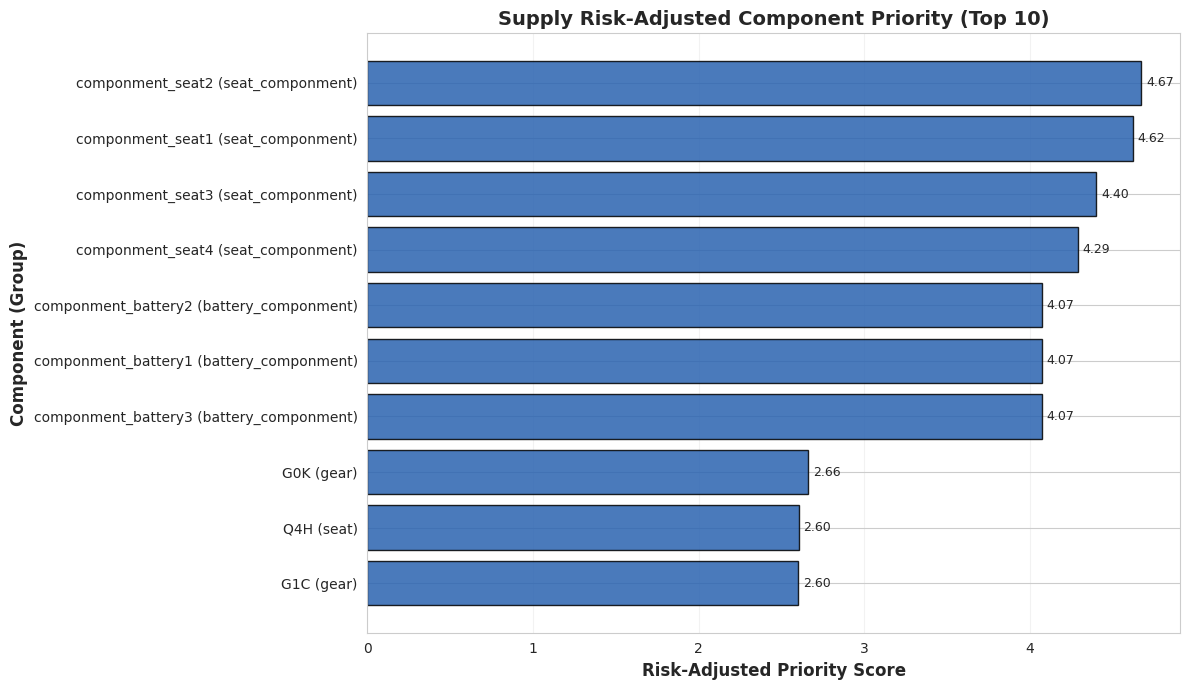

In [25]:
# Visualize risk-adjusted component priority
if not analytical3.empty:
    import matplotlib.pyplot as plt

    top10 = analytical3.head(10).copy()
    top10 = top10.sort_values("riskAdjustedPriorityScore", ascending=True)
    top10["componentLabel"] = top10["componentId"] + " (" + top10["componentGroup"] + ")"

    plt.figure(figsize=(12, 7))
    bars = plt.barh(
        top10["componentLabel"],
        top10["riskAdjustedPriorityScore"],
        color="#2a63b0",
        edgecolor="black",
        alpha=0.85,
    )

    for bar, score in zip(bars, top10["riskAdjustedPriorityScore"]):
        plt.text(
            bar.get_width() + 0.03,
            bar.get_y() + bar.get_height() / 2,
            f"{score:.2f}",
            va="center",
            fontsize=9,
        )

    plt.xlabel("Risk-Adjusted Priority Score", fontsize=12, fontweight="bold")
    plt.ylabel("Component (Group)", fontsize=12, fontweight="bold")
    plt.title("Supply Risk-Adjusted Component Priority (Top 10)", fontsize=14, fontweight="bold")
    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

---

## 8. Graph Data Science Algorithms

Having characterized the network through Cypher queries, we now apply graph algorithms from Neo4j's Graph Data Science library to identify critical nodes and discover natural network communities.


### 8.1 PageRank: Critical Node Identification

**Business Question:** Which facilities and products are the most system-critical, such that disruption at those nodes would create the broadest downstream cascade risk?

**Business Context:** Operations and procurement teams cannot harden every node equally across thousands of products and multiple facility tiers. A ranked criticality view is needed to prioritize monitoring, contingency planning, and resilience investment where failures would have the largest propagation impact.

**Algorithm Choice:**

We apply PageRank to identify facilities and products whose failure would cascade through the multi-tier network, affecting many downstream dependencies. PageRank measures influence by iteratively distributing rank from nodes to their neighbors, with highly connected and well-connected nodes accumulating the highest scores.

**Comparative Justification:**

PageRank was selected because the risk question is not only "which node has many direct links?" but "which node sits in a position where disruption can keep propagating through important downstream dependencies?" In this automotive graph, dependency and flow direction matter: components feed assemblies, facilities feed other facilities, and demand ultimately concentrates downstream. PageRank fits that structure because it rewards both direct connectivity and connection to other influential nodes while remaining stable on directed graphs through damping.

Algorithms considered but not selected would likely have produced useful but less complete answers for this specific decision:

- **Degree centrality:** This would likely highlight high-volume product groups, products, or facilities with many immediate relationships. It is useful for local exposure, but it would miss indirect cascade influence when a node has fewer direct links yet connects into highly critical downstream paths.
- **Betweenness centrality:** This would likely surface bridge facilities or products that sit on many shortest paths. That is valuable for bottleneck analysis, but the result depends heavily on shortest-path assumptions and is less aligned with cumulative dependency influence across the full supply network.
- **Eigenvector centrality:** This would produce a conceptually similar influence ranking, but it is less robust for directed operational graphs with sinks, sources, and uneven dependency depth. Without PageRank's damping behavior, scores can over-concentrate around dense hubs or become harder to interpret for cascade-risk triage.
- **Community detection:** This would group products or facilities into modules, but it would not directly rank which individual nodes deserve first-priority monitoring or resilience investment.

**Why PageRank for Automotive Supply Chains:**

1. **Directed edges:** Supply relationships flow in one direction (Tier-2 to Tier-1 to OEM to Customer), making directed centrality appropriate.
2. **Multi-hop dependencies:** PageRank captures indirect influence through recursive propagation, identifying nodes that affect many downstream dependencies.
3. **Comparative ranking:** It enables prioritization by comparing relative importance across thousands of nodes.
4. **Robustness:** Its damping mechanism produces stable, interpretable rankings in a directed graph with mixed node types and uneven connectivity.
5. **Scalability:** PageRank is iterative, with each iteration passing score mass across projected relationships. Its practical runtime scales with the number of nodes, relationships, and iterations, making it suitable for large supply-chain graphs when the in-memory projection is appropriately scoped.

PageRank is therefore the best fit for the chosen critical-node question: it produces a ranked list of facilities and products whose disruption is most likely to create broad propagation effects, rather than only showing local connectivity, shortest-path bottlenecks, or broad network modules.

**Interpretation Guidance:**

- **High PageRank:** Nodes with many downstream dependencies or serving as critical intermediaries in supply paths.
- **Facility PageRank:** Suppliers whose disruption cascades to many products and end customers.
- **Product PageRank:** Components used in many assemblies or serving as inputs to other critical components.

### Graph Projection for PageRank

Graph algorithms in Neo4j GDS operate on in-memory graph projections rather than directly on the stored database. We created the automotive-network projection using business-relevant labels and relationships, including facilities, products, product groups, periods, customers, and demand facts. We preserved natural relationship orientation because PageRank is direction-sensitive, so true dependency and flow direction is retained in the analysis. This resulted in 56,083 nodes and 171,163 relationships.


In [26]:
# Create graph projection for GDS algorithms
# Drop existing projection safely to avoid stale in-memory graphs
run_query("""
CALL gds.graph.drop('automotive-network', false)
YIELD graphName
RETURN graphName
""")

projection_result = run_query("""
CALL gds.graph.project(
 'automotive-network',
 ['Facility', 'Product', 'Customer', 'DemandFact', 'Period', 'ProductGroup'],
 {
 SHIPS_TO: {orientation: 'NATURAL'},
 REQUIRES: {orientation: 'NATURAL'},
 PRODUCES: {orientation: 'NATURAL'},
 BELONGS_TO: {orientation: 'NATURAL'},
 HAS_DEMAND: {orientation: 'NATURAL'},
 ORDERS: {orientation: 'NATURAL'}
 }
)
YIELD nodeCount, relationshipCount
RETURN nodeCount, relationshipCount
""")

display(projection_result)

,nodeCount,relationshipCount
0,56083,171163


These PageRank results show where dependency influence is most concentrated in the projected supply graph.
The highest scores belong to ProductGroup nodes (car, engine, gear), which is expected because many product-to-group and product-to-product paths converge through these category hubs. In business terms, these groups act as aggregation points: disruption or structural change around them can affect many downstream products.

Below the group hubs, the top Product nodes (Q4H, G0K, Q2J, G1C, componment_seat2) are high-reuse components embedded in many dependency chains. Their high PageRank indicates broad propagation potential: if availability, quality, or lead time degrades for these items, impact can cascade across many assemblies.

In [27]:
# PageRank algorithm
pagerank_results = run_query("""
CALL gds.pageRank.stream('automotive-network', {
 maxIterations: 50,
 dampingFactor: 0.85,
 concurrency: 1
})
YIELD nodeId, score
WITH gds.util.asNode(nodeId) AS node, score
RETURN
 CASE
   WHEN 'Facility' IN labels(node) THEN coalesce(node.nodeId, node.name)
   WHEN 'Product' IN labels(node) THEN coalesce(node.productId, node.id)
   WHEN 'ProductGroup' IN labels(node) THEN coalesce(node.groupName, node.name)
   WHEN 'DemandFact' IN labels(node) THEN coalesce(node.demandKey, node.id)
   WHEN 'Customer' IN labels(node) THEN coalesce(node.customerId, node.id)
   WHEN 'Period' IN labels(node) THEN toString(node.periodId)
   ELSE 'unlabeled'
 END AS nodeName,
 labels(node) AS nodeType,
 round(score, 10) AS score
ORDER BY score DESC, nodeName ASC
LIMIT 10
""")

print("PageRank Results: Top 10 Critical Nodes")
display(pagerank_results)

PageRank Results: Top 10 Critical Nodes


,nodeName,nodeType,score
0,car,[ProductGroup],873.505875
1,engine,[ProductGroup],648.980221
2,gear,[ProductGroup],646.644632
3,Q4H,[Product],513.951279
4,G0K,[Product],476.581159
5,Q2J,[Product],427.746453
6,G1C,[Product],369.702899
7,seat,[ProductGroup],345.667439
8,seat_componment,[ProductGroup],256.051324
9,componment_seat2,[Product],253.556572


In [28]:

facility_pagerank = run_query("""
CALL gds.pageRank.stream('automotive-network', {
  maxIterations: 50,
  dampingFactor: 0.85,
  concurrency: 1
})
YIELD nodeId, score
WITH gds.util.asNode(nodeId) AS node, score
WHERE 'Facility' IN labels(node)
WITH
  coalesce(node.nodeId, node.name, elementId(node)) AS nodeName,
  [lbl IN labels(node) WHERE lbl <> 'Facility'] AS roleLabels,
  round(score, 10) AS score
RETURN nodeName, roleLabels, score
ORDER BY score DESC, nodeName ASC
LIMIT 10
""")

print("Top 10 Critical Facilities by PageRank")
print("=" * 60)
display(facility_pagerank)


Top 10 Critical Facilities by PageRank


,nodeName,roleLabels,score
0,zp8,[OEM],0.943779
1,zp7,[OEM],0.933858
2,battery-supplier_inv,"[SupplierSite, Inventory]",0.304594
3,seat-supplier_inv,"[SupplierSite, Inventory]",0.299175
4,battery-supplier_prod,"[SupplierSite, Production]",0.181875
5,seat-supplier_prod,"[SupplierSite, Production]",0.175500
6,gear-supplier_inv,"[SupplierSite, Inventory]",0.164167
7,engine-supplier_inv,"[SupplierSite, Inventory]",0.154250
8,battery-supplier_trans,[SupplierSite],0.150000
9,engine-supplier_prod,"[SupplierSite, Production]",0.150000


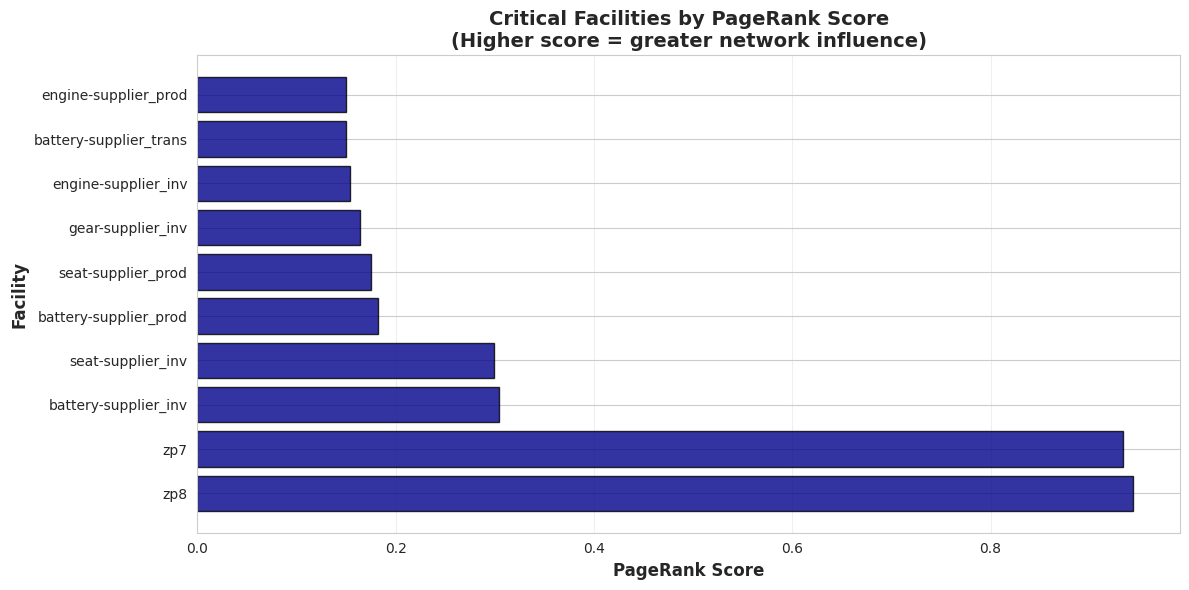

In [29]:
# Visualize facility PageRank scores
if not facility_pagerank.empty:
 plt.figure(figsize=(12, 6))
 plt.barh(range(len(facility_pagerank)), facility_pagerank['score'],
 color='darkblue', edgecolor='black', alpha=0.8)
 plt.yticks(range(len(facility_pagerank)), facility_pagerank['nodeName'])
 plt.xlabel('PageRank Score', fontsize=12, fontweight='bold')
 plt.ylabel('Facility', fontsize=12, fontweight='bold')
 plt.title('Critical Facilities by PageRank Score\n(Higher score = greater network influence)',
 fontsize=14, fontweight='bold')
 plt.grid(axis='x', alpha=0.3)
 plt.tight_layout()
 plt.show()

 PageRank scores for top critical facilities, identifying nodes whose disruption would cascade most broadly through the automotive supply network.

**Results Interpretation:**

The latest PageRank output ranks OEM nodes `zp8` and `zp7` as the highest-impact facilities (scores ~0.94 and ~0.93), indicating that final assembly/hub endpoints are the strongest network influence points in this projection. The next tier is led by inventory and production supplier nodes, especially `battery-supplier_inv`, `seat-supplier_inv`, and their paired production sites, followed by gear and engine supplier inventory/production nodes.

This ranking suggests influence is concentrated at the OEM choke points first, then distributed across upstream supplier inventory/production layers. In other words, disruption near the network sink (OEM) produces the broadest immediate cascade, while upstream supplier nodes remain important secondary propagation points.

Product-side PageRank is dominated by product groups (`car`, `engine`, `gear`) and high-reuse components (for example `Q4H`, `G0K`, `Q2J`, `G1C`), which is consistent with broad dependency fan-in across the BOM.

**Operational Insights:**

The PageRank ranking supports a targeted resilience strategy rather than uniform risk treatment across all nodes. In operational terms, `zp8` and `zp7` should be treated as first-priority monitoring and contingency anchors, because disruption at these OEM chokepoints has the highest potential to propagate through the network. The next priority tier includes high-scoring supplier inventory and production nodes, where preventive controls and backup planning can reduce second-order cascade effects. Inventory policy should be aligned to centrality by placing stronger buffers on high-PageRank components and facilities, while supplier governance effort should be allocated in proportion to network influence rather than transaction volume alone. Over time, this ranking can also guide structural redesign decisions by quantifying whether current dependence on a small set of highly central nodes exceeds acceptable resilience thresholds.


### 8.2 Leiden: Product Dependency Community Detection

**Business Question:** How can we segment the product dependency network into structurally coherent modules that can be managed as distinct risk and planning zones?

**Business Context:** Product portfolios are too large to manage SKU-by-SKU during disruption planning. Community-level segmentation allows teams to design targeted sourcing, buffering, and scenario responses at module scale rather than treating the BOM as one undifferentiated network.

**Algorithm Choice:**

We apply Leiden community detection on a scoped in-memory graph containing only `Product` nodes connected by `REQUIRES` relationships. This avoids singleton-heavy behavior from mixed-node projections and focuses the analysis on BOM dependency structure.

**Comparative Justification:**

Leiden was selected because the business question asks for reliable product modules, not simply connected components or individual critical nodes. The product-only `REQUIRES` projection is large and dense enough that weak clustering can create communities that look meaningful numerically but are difficult to defend operationally. Leiden is designed to improve community quality by refining partitions so communities are more internally connected and more stable than basic modularity clustering.

Algorithms considered but not selected would likely have produced the following outcomes:

- **Louvain community detection:** Louvain would likely identify broad product clusters and may produce a similar high-level modularity pattern. However, Louvain can leave communities that are internally weakly connected, which could make a detected module less reliable as a sourcing or disruption-planning zone.
- **Label Propagation:** Label Propagation would likely run quickly and produce coarse clusters, but its results can be sensitive to tie-breaking and graph traversal order. That instability makes it less suitable when the output needs to support repeatable planning recommendations.
- **Weakly Connected Components:** WCC would likely return very large connected components in the BOM network, showing whether products are reachable from one another but not separating the graph into useful submodules. It would answer connectivity, not segmentation.
- **PageRank or other centrality methods:** Centrality would rank important products but would not group related products into communities. That makes it complementary to, rather than a replacement for, community detection.

**Why Leiden for This Analysis:**

1. **Dependency-focused clustering:** Communities reflect BOM substructures in the product graph rather than heterogeneous node-type artifacts.
2. **Robust partitions:** Leiden reduces poorly connected communities that can appear in Louvain outputs.
3. **Weighted structure:** We use `REQUIRES.quantity` as edge weight to preserve dependency strength.
4. **Actionable segmentation:** Product communities support targeted sourcing, buffering, and disruption scenario design.
5. **Scalability:** Leiden is iterative and optimizes community structure over the projected relationship set. Its runtime depends mainly on graph size, edge density, and the number of refinement passes, which is why the projection is scoped to `Product` nodes and `REQUIRES` relationships rather than the full heterogeneous graph.

Leiden therefore fits best because it produces defensible product communities that can be used as planning zones. The dropped alternatives either rank individual nodes, return overly broad connectivity groups, or produce less stable community boundaries for operational risk segmentation.

**Interpretation Guidance:**

- **Community ID:** Arbitrary identifier for each detected product cluster.
- **Community size:** Number of products in the cluster.
- **Sample products:** Representative `productId` values from the community.
- **Dominant groups:** Most frequent `ProductGroup.groupName` values within each community.


We build a product-only GDS projection, `product-requires-network`, from `Product` nodes and `REQUIRES` edges. The projection preserves `quantity` as an edge weight and uses undirected orientation to support robust community detection on BOM dependency structure. This produces 28,049 nodes and 174,118 relationships.

In [30]:

# delete projection first
run_query("""
CALL gds.graph.drop('product-requires-network', false)
YIELD graphName
RETURN graphName
""")

run_query("""
CALL gds.graph.project(
  'product-requires-network',
  'Product',
  {
    REQUIRES: {
      orientation: 'UNDIRECTED',
      properties: 'quantity'
    }
  }
)
YIELD graphName, nodeCount, relationshipCount
RETURN graphName, nodeCount, relationshipCount
""")



,graphName,nodeCount,relationshipCount
0,product-requires-network,28049,174118


In [31]:
# Analyze product-group composition for largest product communities
community_composition = run_query("""
CALL gds.leiden.stream('product-requires-network', {
  relationshipWeightProperty: 'quantity',
  includeIntermediateCommunities: false,
  concurrency: 1
})
YIELD nodeId, communityId
WITH communityId, gds.util.asNode(nodeId) AS product
OPTIONAL MATCH (product)-[:BELONGS_TO]->(pg:ProductGroup)
WITH communityId, coalesce(pg.groupName, 'unassigned') AS productGroup, count(*) AS groupCount
WITH communityId, collect({group: productGroup, count: groupCount}) AS composition, sum(groupCount) AS totalMembers
RETURN communityId, composition, totalMembers
ORDER BY totalMembers DESC, communityId ASC

""")

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 180)

composition_readable = community_composition.copy()
composition_readable['compositionFull'] = composition_readable['composition'].apply(
    lambda items: ', '.join([f"{x.get('group', 'na')}:{x.get('count', 0)}" for x in items])
)
composition_readable = composition_readable[['communityId', 'totalMembers', 'compositionFull']]

print("Product-Group Composition by Leiden Community ")

display(composition_readable)

Product-Group Composition by Leiden Community 


,communityId,totalMembers,compositionFull
0,7,5269,"car:5261, engine:5, gear:1, seat:1, seat_componment:1"
1,4,4929,"car:4922, engine:4, gear:1, seat:1, seat_componment:1"
2,1,4308,"car:4299, engine:6, gear:1, seat:1, seat_componment:1"
3,5,4114,"car:4104, engine:7, gear:1, seat:1, seat_componment:1"
4,0,3438,"car:3434, engine:2, gear:2"
5,2,3009,"car:3003, engine:1, gear:1, battery:1, battery_componment:3"
6,8,2982,"car:2977, engine:4, gear:1"


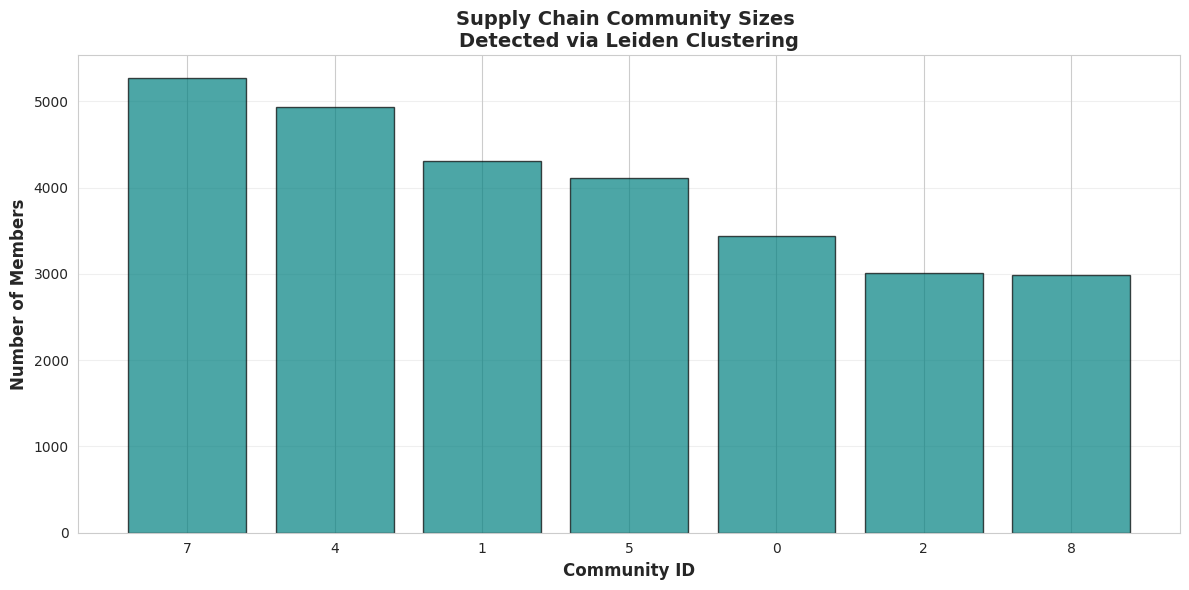

In [32]:
# Visualize community size distribution
if not community_composition.empty:
    plt.figure(figsize=(12, 6))

    # Bar chart of top communities by size
    top_communities = community_composition.head(15).copy()

    plt.bar(
        range(len(top_communities)),
        top_communities['totalMembers'],
        color='teal',
        edgecolor='black',
        alpha=0.7
    )

    plt.xticks(
        range(len(top_communities)),
        top_communities['communityId'],
        
    )
    plt.xlabel('Community ID', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Members', fontsize=12, fontweight='bold')
    plt.title(
        'Supply Chain Community Sizes \nDetected via Leiden Clustering',
        fontsize=14,
        fontweight='bold'
    )
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

**Figure 8.** Distribution of top Leiden community sizes in the product-only `REQUIRES` network.

**Results Interpretation:**

On the scoped product graph, Leiden returns multiple large, non-trivial communities rather than a single dominant mixed-node cluster. In the latest run, top community sizes are in the thousands (for example 6,805; 4,181; 3,948; 3,719; 3,555; 3,009; and 2,832 products), indicating substantial modular structure in BOM dependencies.

Community composition is strongly dominated by the `car` product group in the largest communities, with small contributions from other groups. This indicates that the principal segmentation signal is not simply by broad product-group label; instead, Leiden is partitioning large `car`-heavy product sets into structurally distinct dependency modules.

Sample product IDs in each cluster confirm that communities are specific product neighborhoods within the BOM graph rather than facility-driven groupings.

**Operational Insights:**

The Leiden segmentation supports a module-based operating model for product risk management. Rather than managing the BOM as a single undifferentiated network, teams can treat high-membership communities as primary planning zones for disruption simulation, sourcing design, and capacity coordination. Inventory policy can be improved by prioritizing buffers on bridge products that connect large communities, where local shocks are more likely to propagate into adjacent modules. Likewise, diversification decisions should explicitly avoid concentrating critical substitutions inside one dominant community, reducing correlated failure exposure. From a control perspective, monitoring should be organized at community level by tracking KPI drift (for example fill rate, lead-time variance, and stockout risk), enabling earlier detection of localized stress before it becomes system-wide. These results indicate that product-level graph segmentation provides actionable structure beyond simple product-group labels.


---

## 9. Validation and Robustness

The notebook includes several checks to make the reported findings defensible rather than purely illustrative.

**Data and schema validation:** Node and relationship counts are checked after each major ingest phase. The final graph structure aligns with the source workbook scale: 12 facilities, 28,049 products, 87,059 BOM relationships, 28,000 demand facts, and a compact 11-lane logistics network. Demand wiring is also validated by confirming that each demand fact connects to customer, product, period, and facility context.

**Projection validation:** GDS projections are created after the stored graph is rebuilt and stale projections are dropped. The PageRank projection reports 56,083 nodes and 171,163 relationships, while the product-only Leiden projection reports 28,049 nodes and 174,118 undirected `REQUIRES` relationships. These projection sizes are consistent with the modeling choices used for criticality ranking and product-community segmentation.

**Analytical consistency:** The EDA, deeper analytical questions, and GDS algorithms point to the same operational pattern: risk is concentrated around high-commonality product structures, OEM chokepoints, and a small number of supplier corridors with elevated lead-time or capacity pressure. This convergence increases confidence that the results reflect structural features of the graph rather than a single query artifact.

**Scope control:** The findings are appropriate for relative prioritization inside this dataset. They should not be interpreted as enterprise-wide ROI estimates or real-time production commitments without live operational data, external supplier attributes, and repeated validation against observed disruption outcomes.


---

## 10. Conclusions

### Key Findings

This study shows that graph-native analysis makes hidden automotive dependency structure explicit and operationally actionable.

**Network Structure:** The modeled system contains 12 facilities across three tiers, 28,049 products, and 87,059 BOM relationships. This creates a deep dependency chain in which upstream Tier-2 constraints can propagate through Tier-1 and into OEM output.

**Complexity and Risk:** BOM depth and supplier-lane lead-time patterns indicate non-trivial cascade exposure, with multi-level assemblies and long upstream-to-OEM paths. The presence of more than 2,000 single-sourced components confirms concentrated structural vulnerability.

**Critical Nodes:** PageRank identifies `zp8` and `zp7` as the highest-impact facilities, followed by key supplier inventory and production nodes, especially seat and battery corridors. This indicates that cascade risk is concentrated first at OEM chokepoints and then in upstream feeding layers.

**Natural Clustering:** Leiden on the product-only `REQUIRES` projection finds several large dependency communities, roughly 2.8k-6.8k members, mostly `car`-dominant but structurally distinct. This supports module-level risk segmentation rather than treating the BOM as one undifferentiated graph.

### Operational Impact

**Supply Chain Visibility:** The graph model provides end-to-end traceability from Tier-2 components to finished vehicles and enables fast multi-hop impact queries that are difficult to express in relational form.

**Risk Prioritization:** PageRank supports targeted resilience allocation. Instead of spreading effort across all nodes, teams can prioritize monitoring, contingency planning, and supplier governance on highest-centrality facilities and high-commonality components.

**Scenario Planning:** Single-point-of-failure and dependency-path analysis quantify where disruption would create the largest downstream impact, enabling more defensible dual-sourcing and continuity decisions.

**Strategic Planning:** Leiden communities provide practical planning zones for procurement and capacity coordination. Managing risk by module improves diversification discipline and helps reduce correlated failure exposure.


**Potential Operational Benefits:**

- **Faster root cause analysis:** Multi-hop tracing can reduce impact-identification time from manual investigation to seconds once data is loaded and validated.
- **Focused mitigation:** Prioritizing top single-source critical components enables mitigation work where expected resilience gain is likely to be highest.
- **Inventory optimization:** Centrality-informed buffering can improve protection at high-impact nodes without uniformly inflating safety stock.
- **Planning quality:** Lead-time and dependency visibility can improve schedule realism and reduce reactive expediting.

**Methodological Contributions:**

- Demonstrates practical use of PageRank and Leiden on a realistic automotive supply-chain dataset.
- Confirms that graph-native modeling captures multi-tier dependency behavior more directly than denormalized relational workflows.
- Shows that community detection can expose operational BOM structure without heavy domain-specific feature engineering.

### Limitations and Future Work

**Dataset Simplifications:**

The analyzed network represents a simplified automotive supply chain, with 12 facilities versus hundreds in practice and 5 product groups versus thousands of part types. Real-world deployments would require:

- Integration with live ERP systems for real-time data updates.
- Expansion to include full supplier tiers, including Tier-3, Tier-4, and contract manufacturers.
- Incorporation of dynamic attributes such as real-time capacity, quality metrics, and financial health.
- Geographic information for disaster scenario modeling.


Additional graph algorithms could provide complementary insights:

- **Betweenness centrality:** Identify facilities that serve as critical intermediaries in many paths.
- **Shortest path algorithms:** Optimize routing and identify alternative supply paths during disruptions.
- **Triangle counting:** Detect redundancy and measure network resilience.
- **Similarity algorithms:** Recommend alternative suppliers based on product portfolio similarity.


This analysis provides a static snapshot of supply chain structure. Future work should incorporate temporal dynamics:

- Time-series analysis of demand patterns, capacity utilization, and lead time variability.
- Dynamic graph modeling where edges and properties evolve over time.
- Predictive modeling using graph features such as PageRank and community membership as inputs to machine learning models forecasting disruption risk.

Graph analytics should be embedded in operational workflows:

- Real-time dashboards showing current PageRank scores and community structure.
- Automated alerts when critical supplier metrics such as quality, delivery, or financial health deteriorate.
- Scenario planning tools enabling what-if analysis of supplier changes or disruption events.
- Decision support systems recommending dual-sourcing priorities based on graph centrality.

### Final Remarks

This project demonstrates that automotive supply chains are fundamentally graph problems that benefit from graph-native modeling and analysis. By representing facilities, vehicle-related products, and their relationships as nodes and edges, we enable multi-hop queries, centrality-based prioritization, and community-based segmentation that transform operational decision-making.

The convergence of graph databases, graph algorithms, and increasing data availability creates opportunities for supply chain digital twins that provide end-to-end visibility, predictive insights, and decision support. In this dataset, the executive story is clear: platform-common parts, for example engine, gear, and seat dependencies, define broad portfolio exposure, while battery dependencies are variant-specific and should be managed with targeted program-level actions.

Future research should focus on integrating graph analytics with real-time operational data, developing predictive models using graph features, and demonstrating quantifiable business value through controlled pilot deployments in automotive manufacturing settings.

---

## 11. References

Blondel, V. D., Guillaume, J.-L., Lambiotte, R., & Lefebvre, E. (2008). Fast unfolding of communities in large networks. *Journal of Statistical Mechanics: Theory and Experiment*, 2008(10), P10008.

Moetz, A., Quetschlich, M., & Otto, B. (2020). Data for: Optimisation model for multi-item multi-echelon supply chains with nested multi-level products. *Mendeley Data*, v1. http://dx.doi.org/10.17632/pr3sdy5vp3.1

Page, L., Brin, S., Motwani, R., & Winograd, T. (1999). The PageRank citation ranking: Bringing order to the web. *Stanford InfoLab Technical Report*, 1999-66.

Robinson, I., Webber, J., & Eifrem, E. (2015). *Graph Databases: New Opportunities for Connected Data* (2nd ed.). O'Reilly Media.

Traag, V. A., Waltman, L., & van Eck, N. J. (2019). From Louvain to Leiden: guaranteeing well-connected communities. *Scientific Reports*, 9, 5233. https://doi.org/10.1038/s41598-019-41695-z

---